In [347]:
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.


# Code for plotting and editing data from flash lamp!


### data editing/processing thru pandas

In [348]:
import pandas as pd

# Read CSV
df = pd.read_csv("raw_fla_data.csv")

# Check column names
print("Columns:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

# Store each lamp setting's data
data = {}

for i in range(0, len(df.columns), 2):

    time_col = df.columns[i]
    current_col = df.columns[i + 1]

    # Extract lamp setting
    lamp = int(time_col.split()[2])

    # Convert to numeric
    time = pd.to_numeric(df[time_col], errors="coerce")
    current = pd.to_numeric(df[current_col], errors="coerce")

    # Create dataframe
    lamp_data = pd.DataFrame({
        "Relative Time (s)": time,
        "Current (A)": current
    })

    # Remove missing values
    lamp_data = lamp_data.dropna()

    # ============================================================
    # Ignore current values below 1.5e-6 A
    # ============================================================
    lamp_data = lamp_data[
        lamp_data["Current (A)"] >= 1.5e-6
    ].copy()

    # Skip this lamp if no valid data remains
    if lamp_data.empty:
        print(f"Lamp {lamp}: no data above 1.5e-6 A")
        continue

    # Normalize time so that the first remaining time value is 0
    lamp_data["Time (s)"] = (
        lamp_data["Relative Time (s)"]
        - lamp_data["Relative Time (s)"].iloc[0]
    )

    # Calculate resistance: R = V/I, where V = 0.5 V
    lamp_data["Resistance (Ω)"] = (
        0.5 / lamp_data["Current (A)"]
    )

    # Store data
    data[lamp] = lamp_data

print("\nCurrent threshold: 1.5e-6 A")
print(f"Lamp settings retained: {list(data.keys())}")

Columns:
0 'Relative Time 300 (s)'
1 'Current 300 (A)'
2 'Relative Time 350 (s)'
3 'Current 350 (A)'
4 'Relative Time 400 (s)'
5 'Current 400 (A)'
6 'Relative Time 425 (s)'
7 'Current 425 (A)'
8 'Relative Time 450 (s)'
9 'Current 450 (A)'
10 'Relative Time 475 (s)'
11 'Current 475 (A)'
12 'Relative Time 500 (s)'
13 'Current 500 (A)'
14 'Relative Time 525 (s)'
15 'Current 525 (A)'
16 'Relative Time 550 (s)'
17 'Current 550 (A)'
18 'Relative Time 575 (s)'
19 'Current 575 (A)'
20 'Relative Time 600 (s)'
21 'Current 600 (A)'
22 'Relative Time 615'
23 'Current 615 (A)'

Current threshold: 1.5e-6 A
Lamp settings retained: [300, 350, 400, 425, 450, 475, 500, 525, 550, 575, 600, 615]


In [349]:
for lamp, lamp_data in data.items():
    globals()[f"df_{lamp}"] = lamp_data

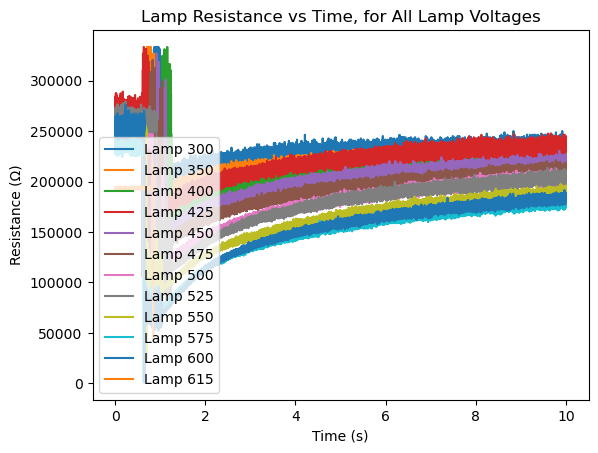

In [350]:
import matplotlib.pyplot as plt

for lamp, lamp_data in data.items():
    plt.plot(
        lamp_data["Time (s)"],
        lamp_data["Resistance (Ω)"],
        label=f"Lamp {lamp}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ω)")
plt.title("Lamp Resistance vs Time, for All Lamp Voltages")
plt.legend()
plt.show()

Lamp 615 V:
Resistance at 5 s: 53361.79 Ω
Closest measured time: 0.847300 s


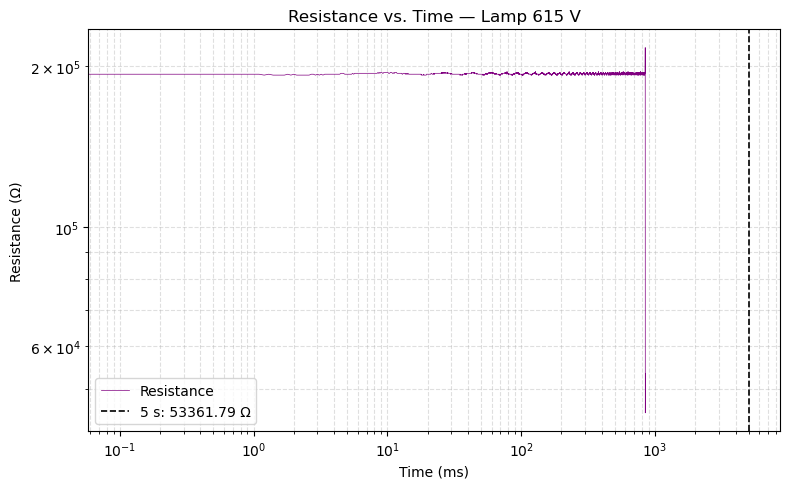

In [351]:
#plot 615 data
# ============================================================
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

lamp = 615

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find the measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.5,
    label="Resistance",
    c="purple"
)

# Vertical line at 5 seconds = 5000 ms
plt.axvline(
    x=5000,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"5 s: {resistance_at_5s:.2f} Ω"
)

#plt.xlim(0, 10000)  # Limit x-axis to 10 seconds (10000 ms)

# Logarithmic y-axis
plt.yscale("log")
plt.xscale("log")

# Labels and title
plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title("Resistance vs. Time — Lamp 615 V")

# Grid
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

## plots the current vs time and resistance vs time graphs for each lamp voltage setting!

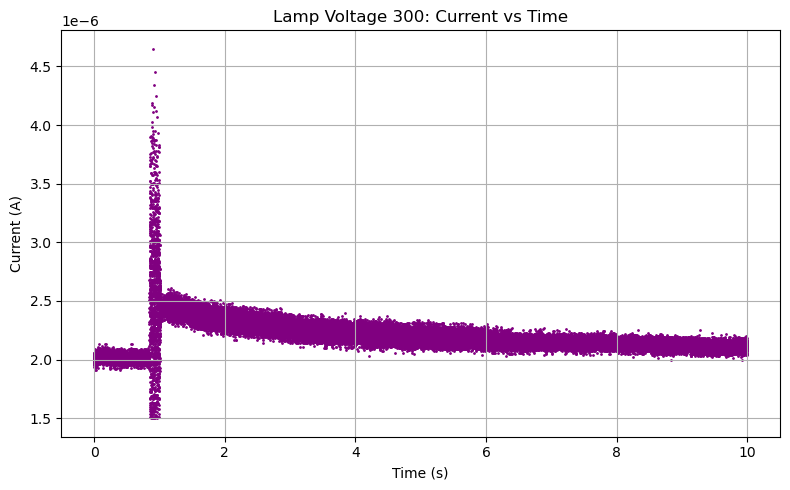

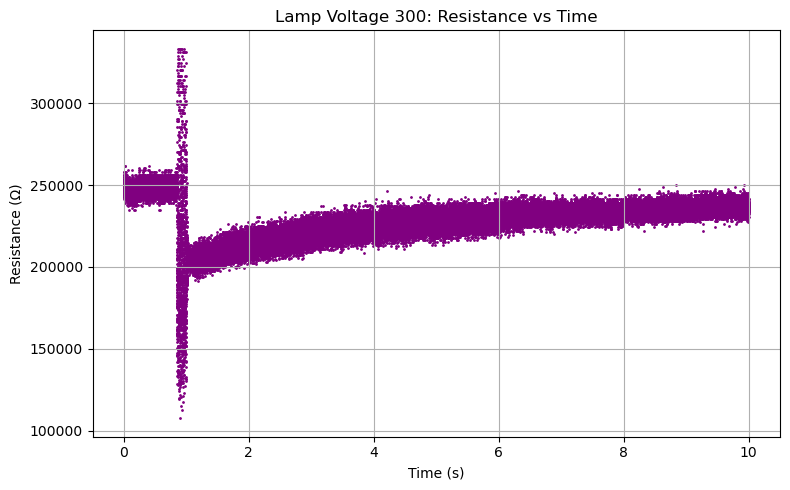

Lamp Voltage 300:
  Highest current: 4.650000e-06 A
  Lowest resistance:  1.075269e+05 Ω



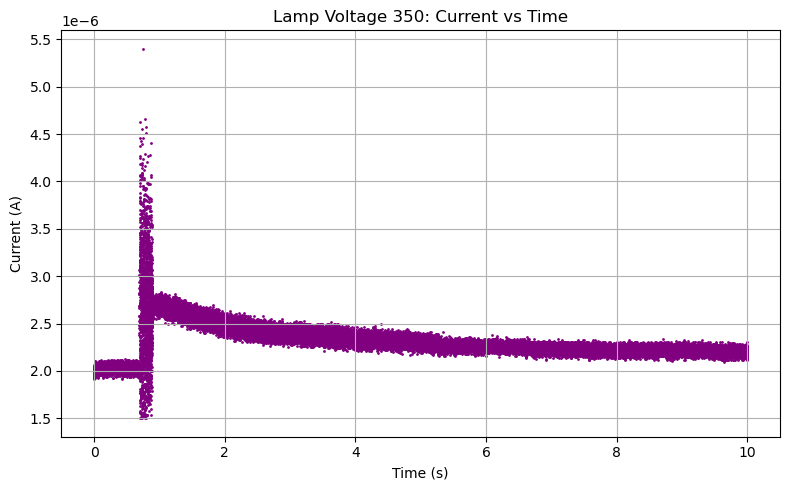

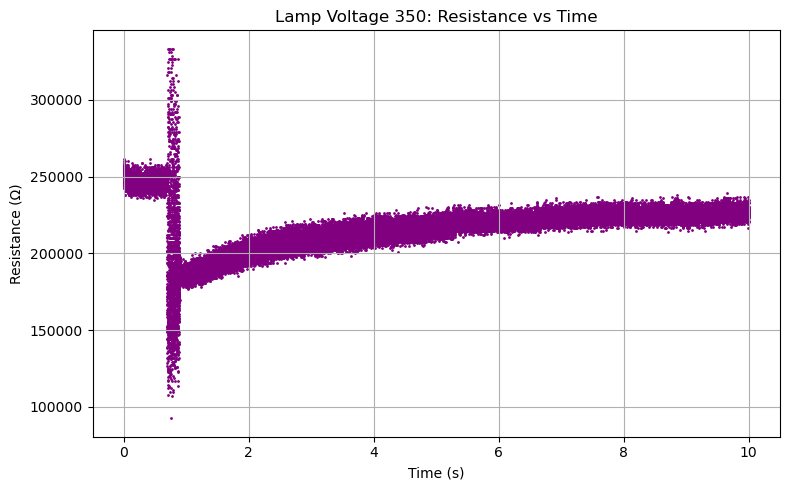

Lamp Voltage 350:
  Highest current: 5.400000e-06 A
  Lowest resistance:  9.259259e+04 Ω



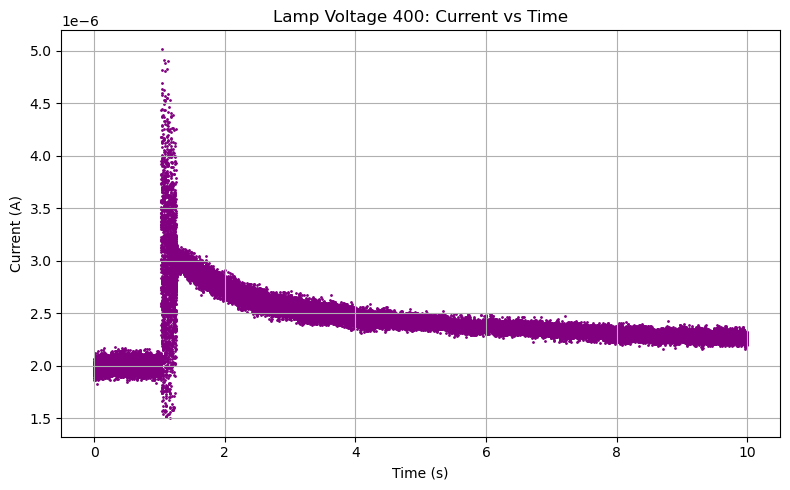

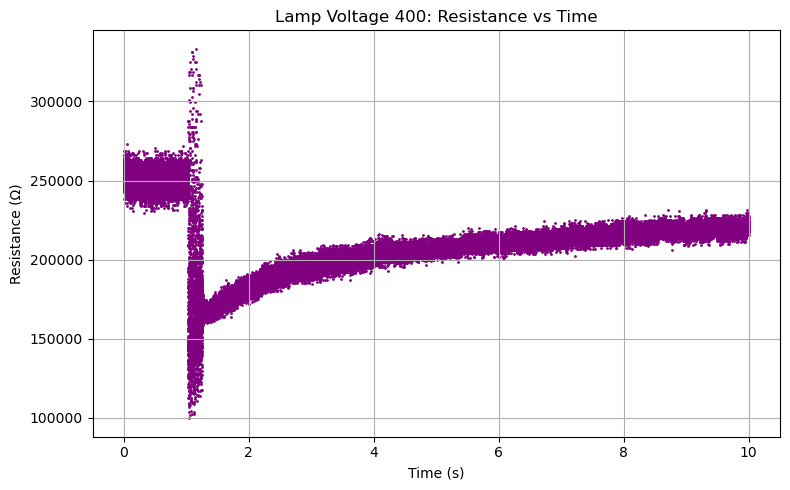

Lamp Voltage 400:
  Highest current: 5.020000e-06 A
  Lowest resistance:  9.960159e+04 Ω



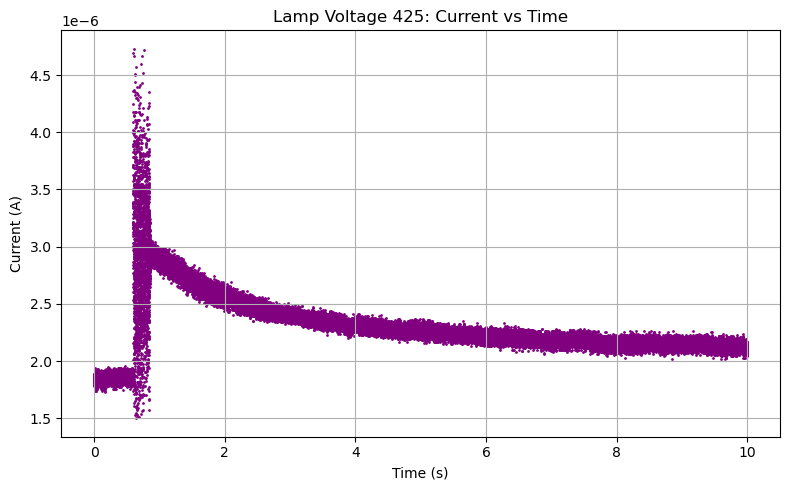

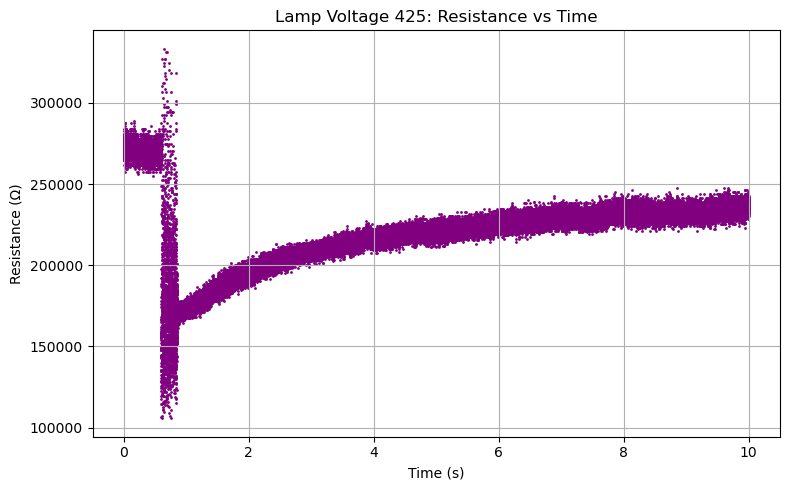

Lamp Voltage 425:
  Highest current: 4.730000e-06 A
  Lowest resistance:  1.057082e+05 Ω



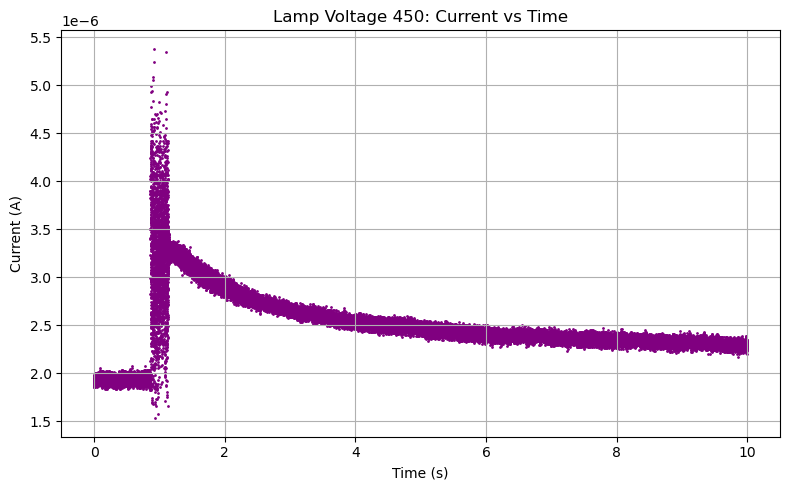

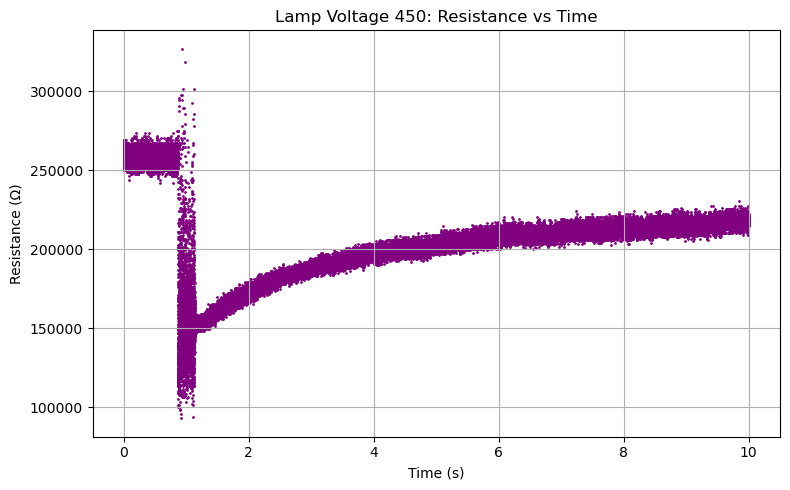

Lamp Voltage 450:
  Highest current: 5.380000e-06 A
  Lowest resistance:  9.293680e+04 Ω



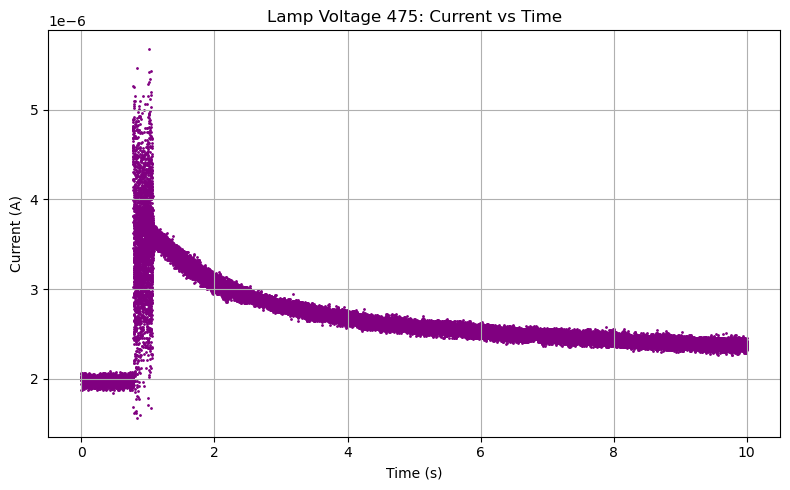

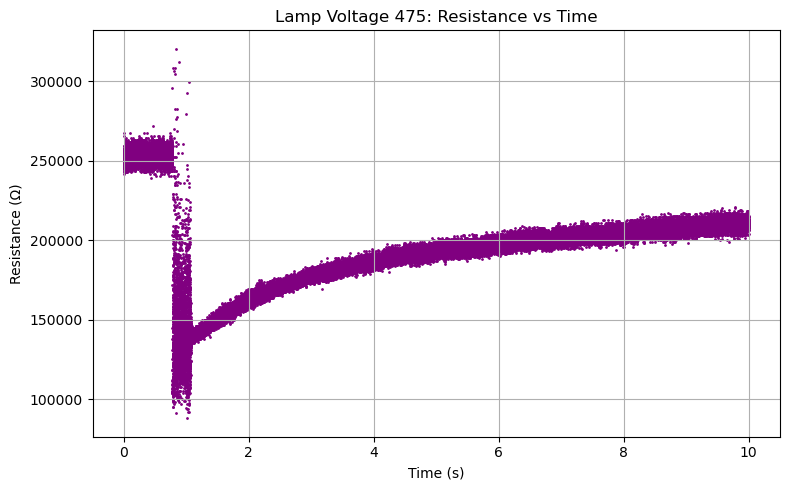

Lamp Voltage 475:
  Highest current: 5.680000e-06 A
  Lowest resistance:  8.802817e+04 Ω



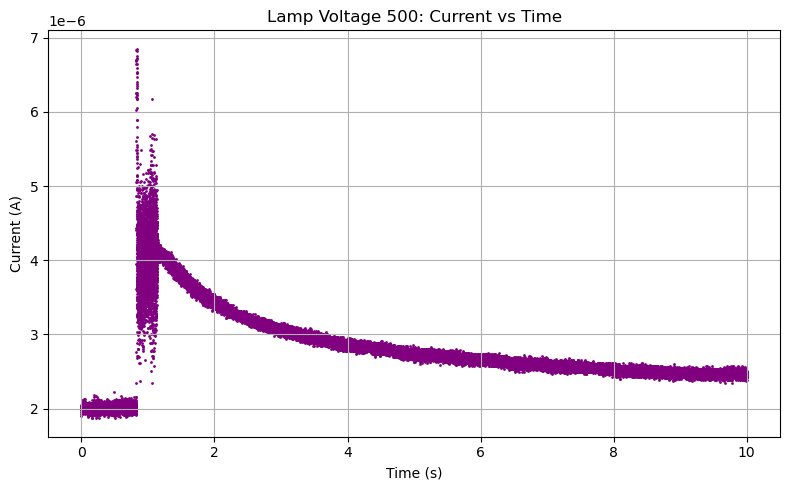

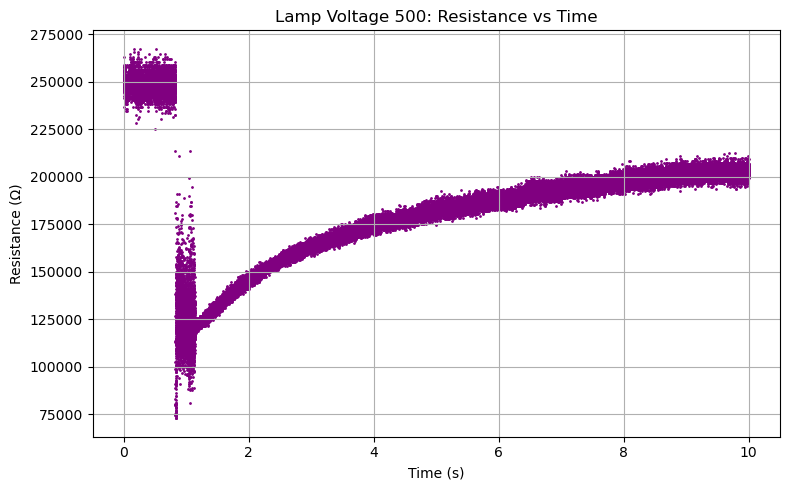

Lamp Voltage 500:
  Highest current: 6.850000e-06 A
  Lowest resistance:  7.299270e+04 Ω



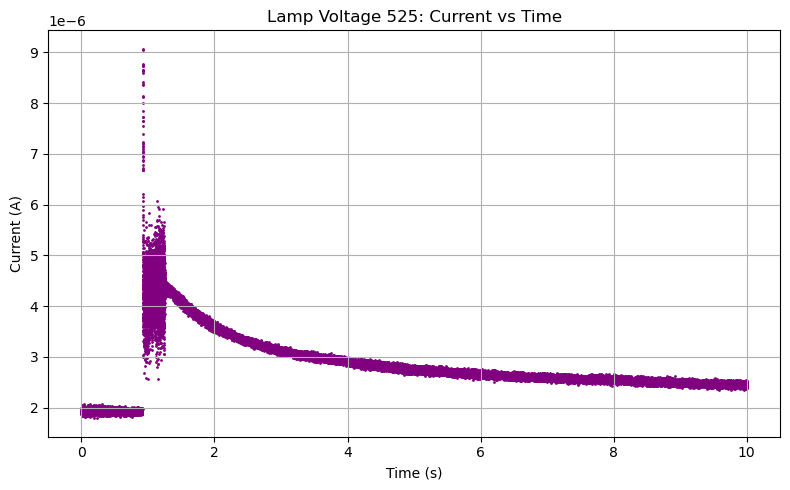

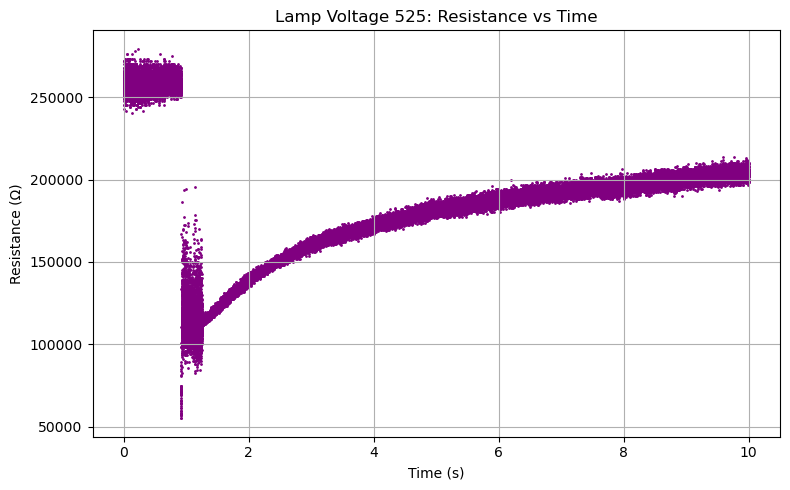

Lamp Voltage 525:
  Highest current: 9.070000e-06 A
  Lowest resistance:  5.512679e+04 Ω



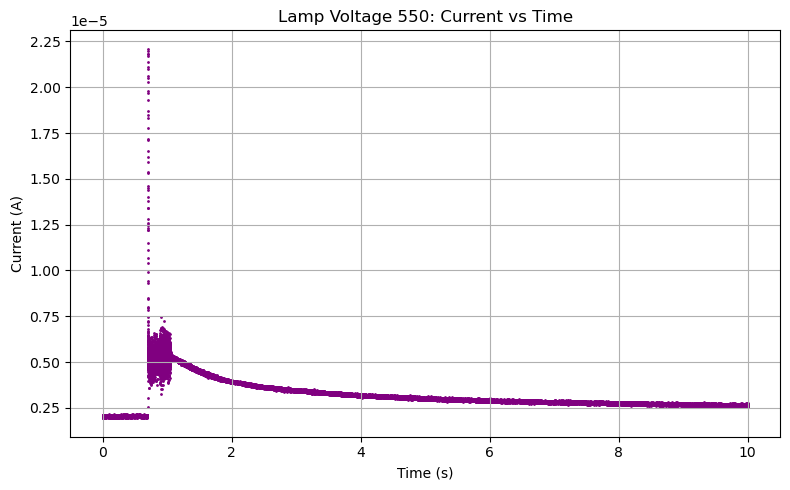

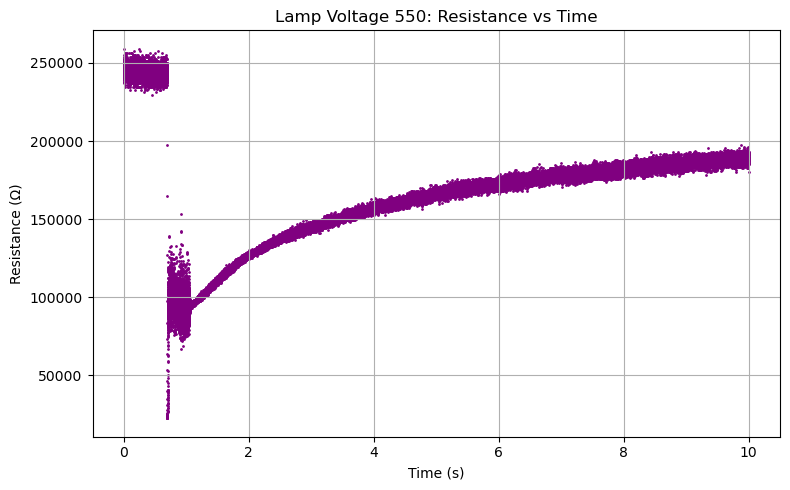

Lamp Voltage 550:
  Highest current: 2.210000e-05 A
  Lowest resistance:  2.262443e+04 Ω



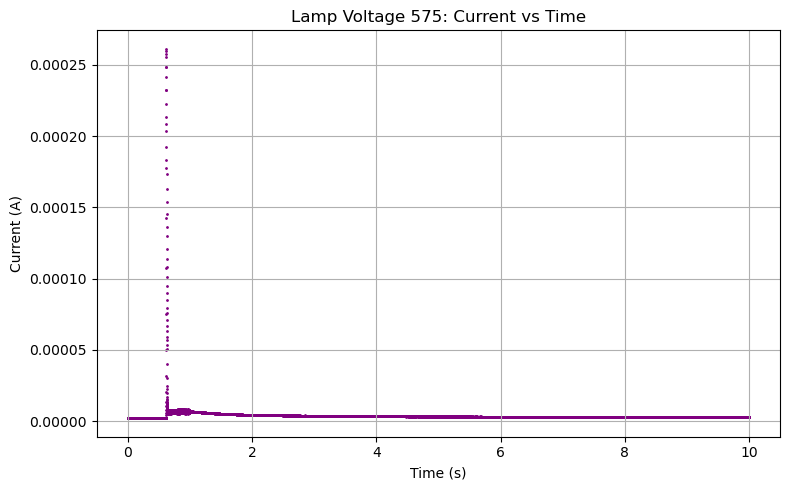

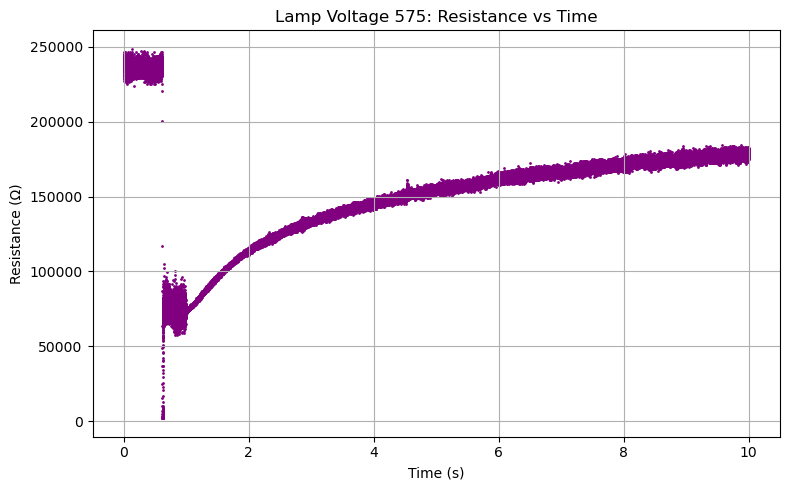

Lamp Voltage 575:
  Highest current: 2.612600e-04 A
  Lowest resistance:  1.913802e+03 Ω



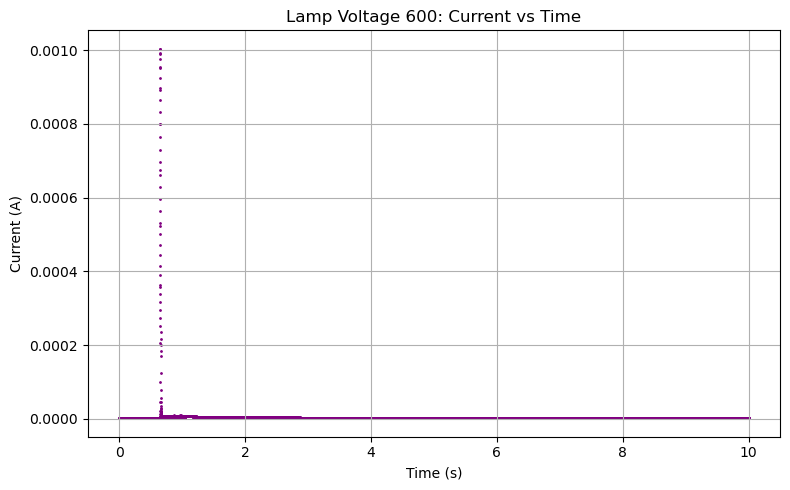

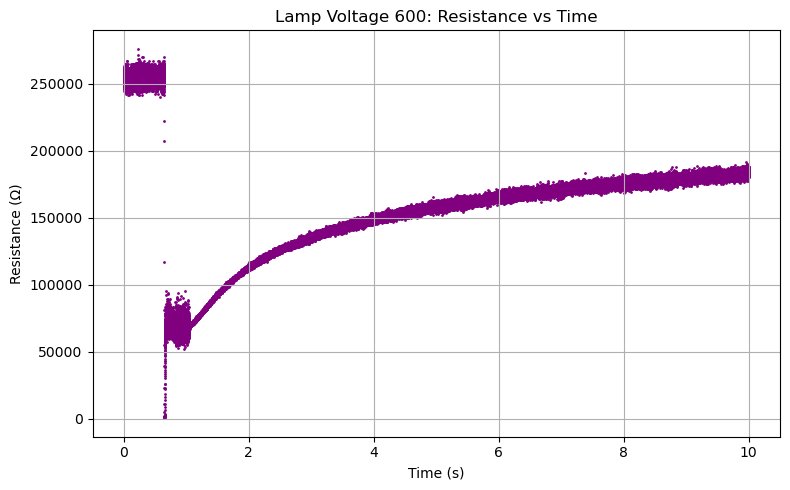

Lamp Voltage 600:
  Highest current: 1.003757e-03 A
  Lowest resistance:  4.981285e+02 Ω



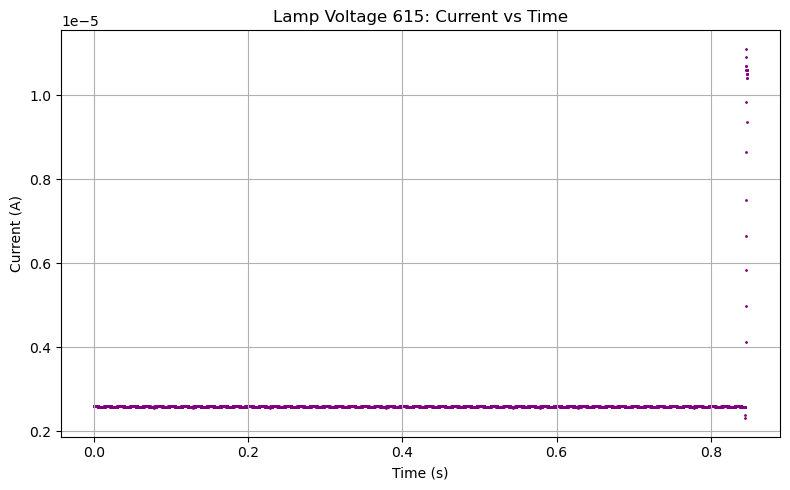

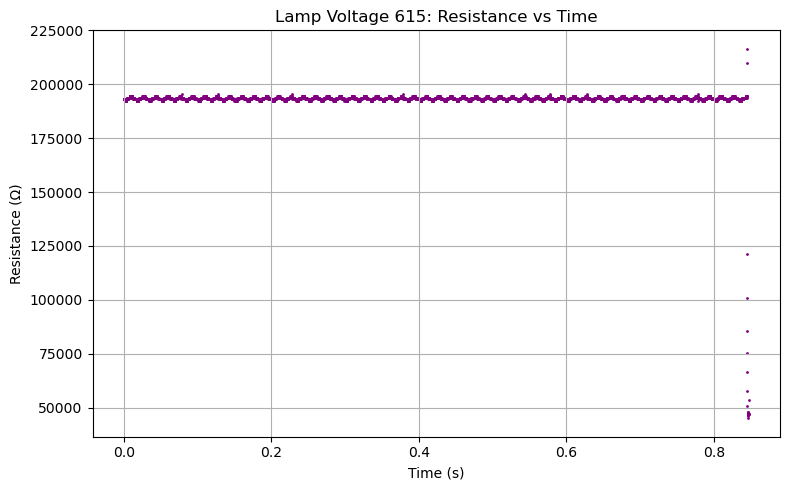

Lamp Voltage 615:
  Highest current: 1.110000e-05 A
  Lowest resistance:  4.504505e+04 Ω



In [352]:
# Loop through each lamp setting
for lamp, lamp_data in data.items():

    # -------------------------
    # Time vs Current
    # -------------------------
    plt.figure(figsize=(8, 5))
    
    plt.scatter(
        lamp_data["Time (s)"],
        lamp_data["Current (A)"],
        s=1,
        c='purple'
    )
    
    plt.xlabel("Time (s)")
    plt.ylabel("Current (A)")
    plt.title(f"Lamp Voltage {lamp}: Current vs Time")

    plt.grid(True)
    plt.tight_layout()

    #plt.savefig(f"Lamp_{lamp}_Current_vs_Time.png", dpi=300)
    plt.show()

    # -------------------------
    # Time vs Resistance
    # -------------------------
    plt.figure(figsize=(8, 5))
    
    plt.scatter(
        lamp_data["Time (s)"],
        lamp_data["Resistance (Ω)"],
        s=1,
        c='purple'
    )
    
    plt.xlabel("Time (s)")
    plt.ylabel("Resistance (Ω)")
    plt.title(f"Lamp Voltage {lamp}: Resistance vs Time")
    plt.grid(True)
    plt.tight_layout()

    #plt.savefig(f"Lamp_{lamp}_Resistance_vs_Time.png", dpi=300)
    plt.show()

    # -------------------------
    # Maximum and minimum current
    # -------------------------
    max_current = lamp_data["Current (A)"].max()
    min_resistance = lamp_data["Resistance (Ω)"].min()

    print(f"Lamp Voltage {lamp}:")
    print(f"  Highest current: {max_current:.6e} A")
    print(f"  Lowest resistance:  {min_resistance:.6e} Ω")
    print()

## some separate graphing

In [353]:
# %pip install plotly

In [354]:
# # ============================================================
# # Interactive Current and Resistance vs. Time
# # ============================================================

# import plotly.graph_objects as go

# selected_lamps = [400, 550, 575]

# for lamp in selected_lamps:

#     lamp_data = data[lamp]

#     time = lamp_data["Time (s)"].to_numpy()
#     current = lamp_data["Current (A)"].to_numpy()
#     resistance = lamp_data["Resistance (Ω)"].to_numpy()

#     # Remove invalid values
#     current_mask = np.isfinite(time) & np.isfinite(current)
#     resistance_mask = np.isfinite(time) & np.isfinite(resistance)

#     # ============================================================
#     # Current vs. Time
#     # ============================================================

#     fig_current = go.Figure()

#     fig_current.add_trace(
#         go.Scatter(
#             x=time[current_mask] * 1e3,
#             y=current[current_mask],
#             mode="lines",
#             name="Current"
#         )
#     )

#     fig_current.update_layout(
#         title=f"Current vs. Time — Lamp {lamp}",
#         xaxis_title="Time (ms)",
#         yaxis_title="Current (A)",
#         hovermode="x unified",
#         template="plotly_white"
#     )

#     fig_current.show()

#     # ============================================================
#     # Resistance vs. Time
#     # ============================================================

#     fig_resistance = go.Figure()

#     fig_resistance.add_trace(
#         go.Scatter(
#             x=time[resistance_mask] * 1e3,
#             y=resistance[resistance_mask],
#             mode="lines",
#             name="Resistance"
#         )
#     )

#     fig_resistance.update_layout(
#         title=f"Resistance vs. Time — Lamp {lamp}",
#         xaxis_title="Time (ms)",
#         yaxis_title="Resistance (Ω)",
#         hovermode="x unified",
#         template="plotly_white"
#     )

#     fig_resistance.show()

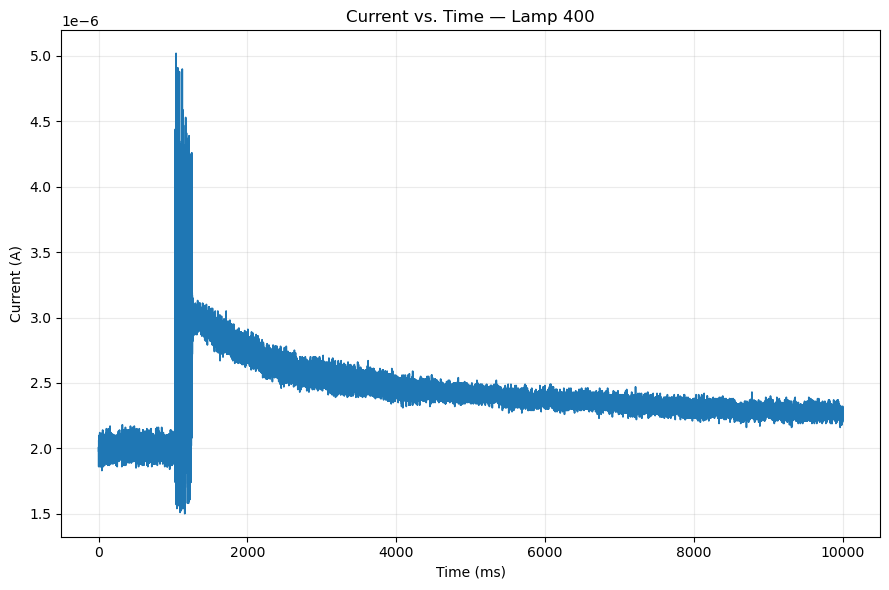

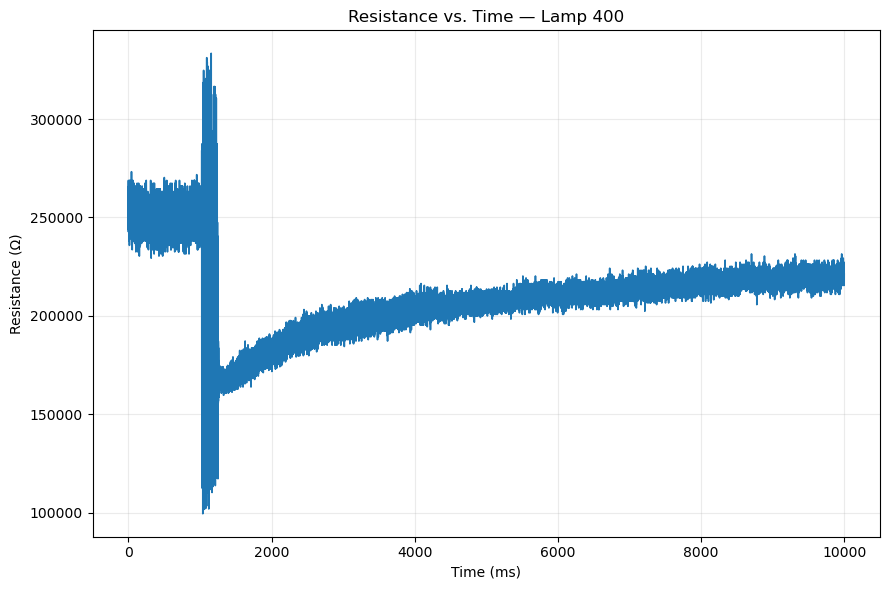

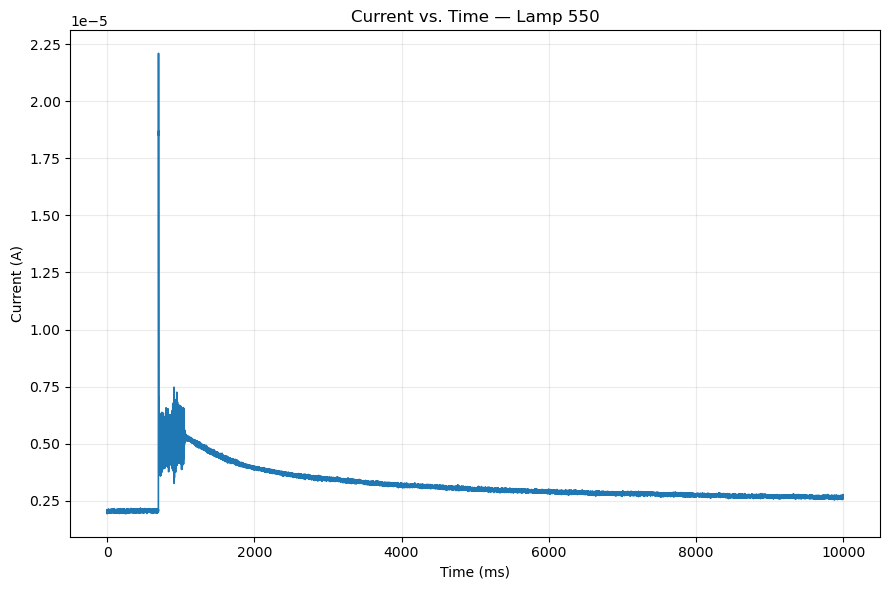

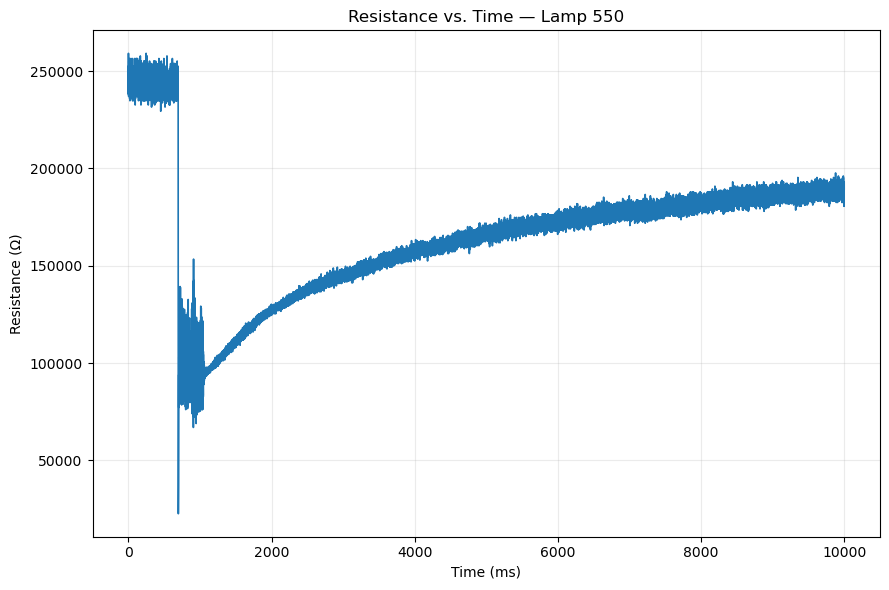

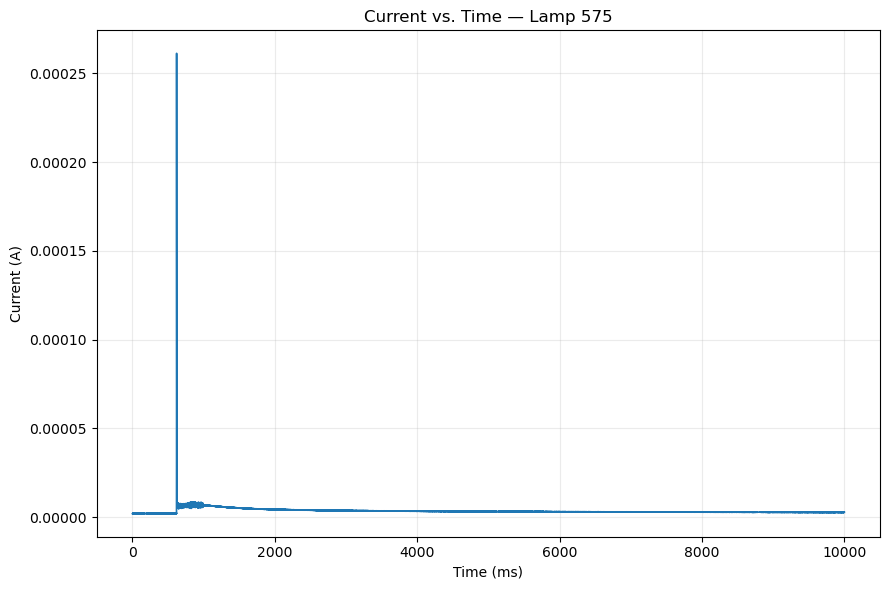

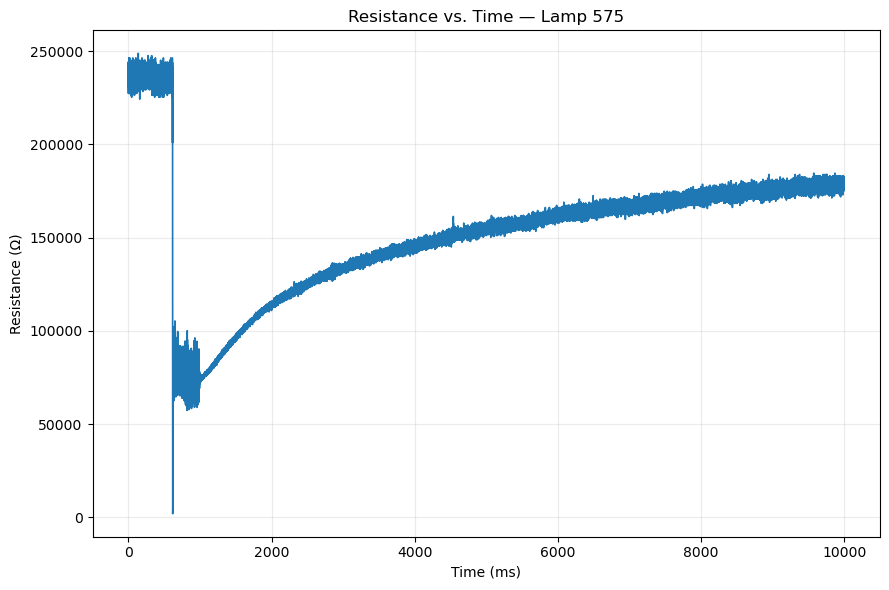

In [355]:
# ============================================================
# Plot Current and Resistance vs. Time for Selected Lamp Settings
# ============================================================

selected_lamps = [400, 550, 575]

for lamp in selected_lamps:

    # Get data
    lamp_data = data[lamp]

    time = lamp_data["Time (s)"].to_numpy()
    current = lamp_data["Current (A)"].to_numpy()
    resistance = lamp_data["Resistance (Ω)"].to_numpy()

    # Remove invalid values
    current_mask = np.isfinite(time) & np.isfinite(current)
    resistance_mask = np.isfinite(time) & np.isfinite(resistance)

    # ------------------------------------------------------------
    # Current vs. Time
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(
        time[current_mask] * 1e3,
        current[current_mask],
        linewidth=1.2
    )

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Current (A)")
    ax.set_title(f"Current vs. Time — Lamp {lamp}")
    ax.grid(True, alpha=0.25)

    fig.tight_layout()

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------
    # Resistance vs. Time
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(
        time[resistance_mask] * 1e3,
        resistance[resistance_mask],
        linewidth=1.2
    )

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Resistance (Ω)")
    ax.set_title(f"Resistance vs. Time — Lamp {lamp}")
    ax.grid(True, alpha=0.25)

    fig.tight_layout()

    plt.show()
    plt.close(fig)

In [356]:
# Resistance Change at Lamp Voltage = 575
# ============================================================
import numpy as np

lamp = 575

# Get resistance data
resistance = data[lamp]["Resistance (Ω)"].to_numpy()

# Remove NaN / infinite values
resistance = resistance[np.isfinite(resistance)]

# Find minimum and maximum resistance
R_min = np.min(resistance)
R_max = np.max(resistance)

# Calculate magnitude of resistance change
delta_R = R_max - R_min

print(f"Lamp voltage: {lamp}")
print(f"Lowest resistance:  {R_min:.4f} Ω")
print(f"Highest resistance: {R_max:.4f} Ω")
print(f"Resistance change:  {delta_R:.4f} Ω")

percent_change = (R_max - R_min) / R_min * 100

print(f"Percentage resistance change: {percent_change:.2f}%")

Lamp voltage: 575
Lowest resistance:  1913.8023 Ω
Highest resistance: 248756.2189 Ω
Resistance change:  246842.4166 Ω
Percentage resistance change: 12898.01%


In [357]:
# Maximum / Minimum Resistance and Rmax/Rmin for Each Lamp
# ============================================================

results = []

for lamp, lamp_data in data.items():

    # Ignore lamp 615
    if lamp == 615:
        continue

    resistance = lamp_data["Resistance (Ω)"].to_numpy()

    # Remove NaN / infinite values
    resistance = resistance[np.isfinite(resistance)]

    # Find minimum and maximum resistance
    R_min = np.min(resistance)
    R_max = np.max(resistance)

    # Ratio
    R_ratio = R_max / R_min

    # Percentage change
    percent_change = (R_max - R_min) / R_min * 100

    results.append({
        "Lamp Voltage": lamp,
        "R_min (Ω)": R_min,
        "R_max (Ω)": R_max,
        "R_max / R_min": R_ratio,
        "Resistance Change (%)": percent_change
    })

# Convert results to DataFrame
resistance_results = pd.DataFrame(results)

# Sort by lamp voltage
resistance_results = resistance_results.sort_values(
    "Lamp Voltage"
).reset_index(drop=True)

# Display
print(resistance_results.to_string(index=False))

 Lamp Voltage     R_min (Ω)     R_max (Ω)  R_max / R_min  Resistance Change (%)
          300 107526.881720 333333.333333       3.100000             210.000000
          350  92592.592593 333333.333333       3.600000             260.000000
          400  99601.593625 333333.333333       3.346667             234.666667
          425 105708.245243 333333.333333       3.153333             215.333333
          450  92936.802974 326797.385621       3.516340             251.633987
          475  88028.169014 320512.820513       3.641026             264.102564
          500  72992.700730 267379.679144       3.663102             266.310160
          525  55126.791621 279329.608939       5.067039             406.703911
          550  22624.434389 259067.357513      11.450777            1045.077720
          575   1913.802342 248756.218905     129.980100           12898.009950
          600    498.128531 276243.093923     554.561878           55356.187845


## generates lowest resistances and plots against lamp voltage normally & in log scale

Lowest resistance for each lamp setting:
Lamp 300: 107526.88 Ω
Lamp 350: 92592.59 Ω
Lamp 400: 99601.59 Ω
Lamp 425: 105708.25 Ω
Lamp 450: 92936.80 Ω
Lamp 475: 88028.17 Ω
Lamp 500: 72992.70 Ω
Lamp 525: 55126.79 Ω
Lamp 550: 22624.43 Ω
Lamp 575: 1913.80 Ω
Lamp 600: 498.13 Ω
Lamp 615: 45045.05 Ω


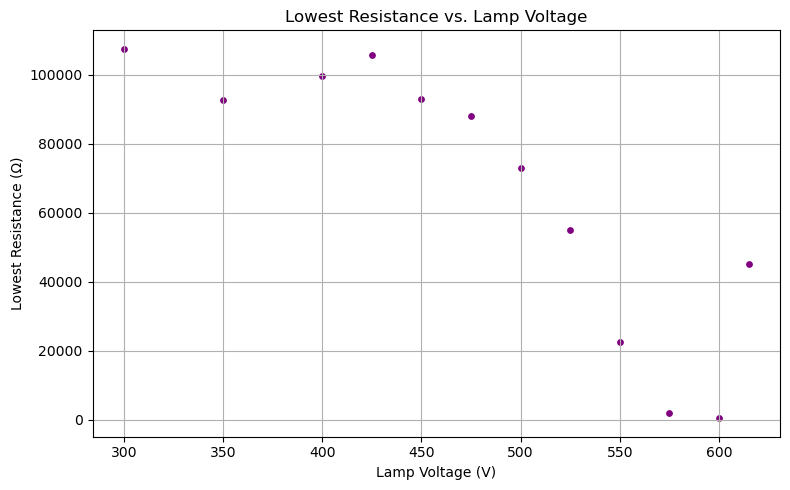

    Lamp  Lowest Resistance (Ω)
0    300          107526.881720
1    350           92592.592593
2    400           99601.593625
3    425          105708.245243
4    450           92936.802974
5    475           88028.169014
6    500           72992.700730
7    525           55126.791621
8    550           22624.434389
9    575            1913.802342
10   600             498.128531
11   615           45045.045045


In [358]:
# Store lowest resistance for each lamp setting
lowest_resistances = {}

for lamp, lamp_data in data.items():
    lowest_resistances[lamp] = lamp_data["Resistance (Ω)"].min()

# Print the results
print("Lowest resistance for each lamp setting:")
for lamp, resistance in lowest_resistances.items():
    print(f"Lamp {lamp}: {resistance:.2f} Ω")

# Plot lowest resistance vs. lamp setting
plt.figure(figsize=(8, 5))

plt.scatter(
    list(lowest_resistances.keys()),
    list(lowest_resistances.values()),
    marker="o",
    color="purple",
    s=15
)

plt.xlabel("Lamp Voltage (V)")
plt.ylabel("Lowest Resistance (Ω)")
plt.title("Lowest Resistance vs. Lamp Voltage")
plt.grid(True)
plt.tight_layout()
plt.show()

lowest_resistance_df = pd.DataFrame({
    "Lamp": list(lowest_resistances.keys()),
    "Lowest Resistance (Ω)": list(lowest_resistances.values())
})

print(lowest_resistance_df)

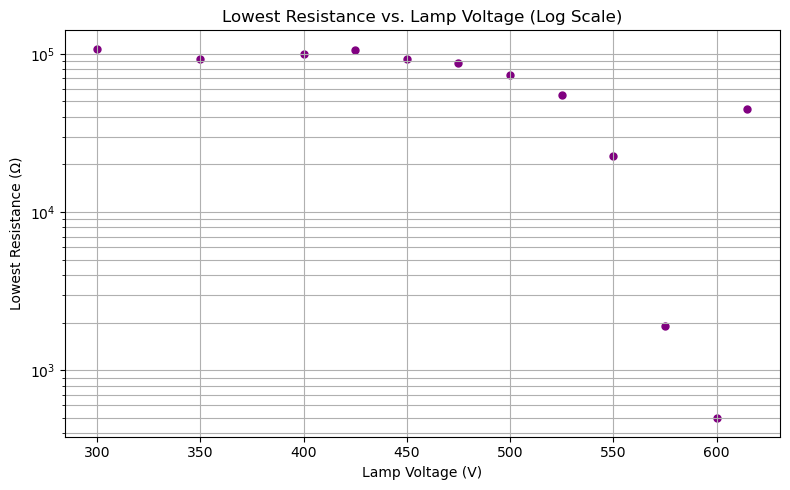

In [359]:
# Plot lowest resistance vs. lamp setting on a log scale

plt.figure(figsize=(8, 5))

plt.scatter(
    list(lowest_resistances.keys()),
    list(lowest_resistances.values()),
    marker="o",
    s=25,
    color = "purple"
)

# Set y-axis to logarithmic scale
plt.yscale("log")

plt.xlabel("Lamp Voltage (V)")
plt.ylabel("Lowest Resistance (Ω)")
plt.title("Lowest Resistance vs. Lamp Voltage (Log Scale)")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

#CHANGE TO VERSUS SIMULATION TEMPERATURE

## applying fits


Exponential decay fit in log space:
ln(R) = 11057.8 * exp(-1.04499e-06 * V) + -11041.8
R(V) = exp(11057.8 * exp(-1.04499e-06 * V) + -11041.8)
R² (log space) = 0.427984


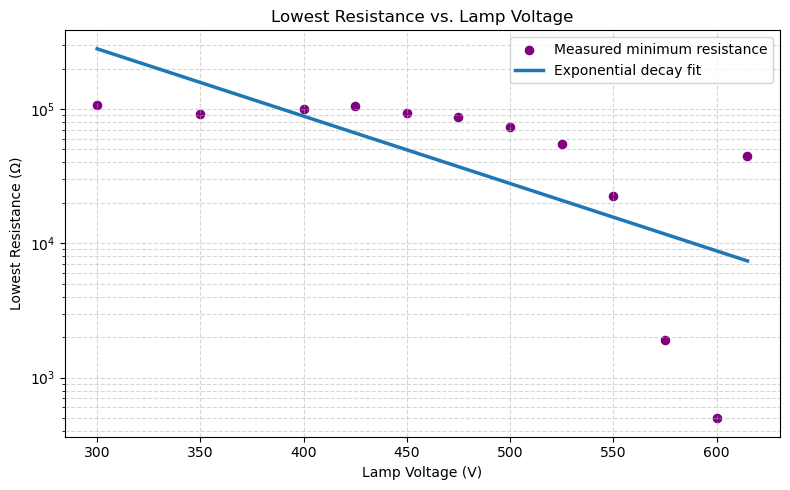

In [360]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Lowest Resistance vs. Lamp Voltage
# Exponential Decay Fit in Log Space
# ============================================================

# Extract data
lamp_voltages = np.array(list(lowest_resistances.keys()), dtype=float)
lowest_R = np.array(list(lowest_resistances.values()), dtype=float)

# Sort by lamp voltage
sort_idx = np.argsort(lamp_voltages)
lamp_voltages = lamp_voltages[sort_idx]
lowest_R = lowest_R[sort_idx]

# Make sure all resistance values are positive
mask = (
    np.isfinite(lamp_voltages)
    & np.isfinite(lowest_R)
    & (lowest_R > 0)
)

V = lamp_voltages[mask]
R = lowest_R[mask]

# ------------------------------------------------------------
# Fit the LOG of resistance
#
# ln(R) = a * exp(-b*V) + c
#
# This produces a decreasing slope that gradually flattens.
# ------------------------------------------------------------

log_R = np.log(R)

def log_decay(V, a, b, c):
    return a * np.exp(-b * V) + c

# Initial guesses
initial_guess = [
    -0.1,  # a
    0.005,                       # b
    log_R.max()                  # c
]

# Fit in log space
popt, pcov = curve_fit(
    log_decay,
    V,
    log_R,
    p0=initial_guess,
    maxfev=100000
)

a, b, c = popt

# ------------------------------------------------------------
# Generate smooth fitted curve
# ------------------------------------------------------------

V_fit = np.linspace(V.min(), V.max(), 500)

# Fit is calculated in log space
log_R_fit = log_decay(V_fit, a, b, c)

# Convert fit back into resistance
R_fit = np.exp(log_R_fit)

# ------------------------------------------------------------
# Calculate R² in LOG space
# ------------------------------------------------------------

log_R_pred = log_decay(V, a, b, c)

ss_res = np.sum((log_R - log_R_pred) ** 2)
ss_tot = np.sum((log_R - np.mean(log_R)) ** 2)

r_squared = 1 - ss_res / ss_tot

print("\nExponential decay fit in log space:")
print(f"ln(R) = {a:.6g} * exp(-{b:.6g} * V) + {c:.6g}")
print(f"R(V) = exp({a:.6g} * exp(-{b:.6g} * V) + {c:.6g})")
print(f"R² (log space) = {r_squared:.6f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    V,
    R,
    marker="o",
    s=35,
    color="purple",
    label="Measured minimum resistance"
)

plt.plot(
    V_fit,
    R_fit,
    linewidth=2.5,
    label="Exponential decay fit"
)

# Logarithmic y-axis
plt.yscale("log")

plt.xlabel("Lamp Voltage (V)")
plt.ylabel("Lowest Resistance (Ω)")
plt.title("Lowest Resistance vs. Lamp Voltage")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Exponential Decay Fit
R(V) = R_offset + A * exp(-V / V0)
A        = 425914 Ω
V0       = 248.75 V
R_offset = 8.16044e-09 Ω
R²       = 0.611957


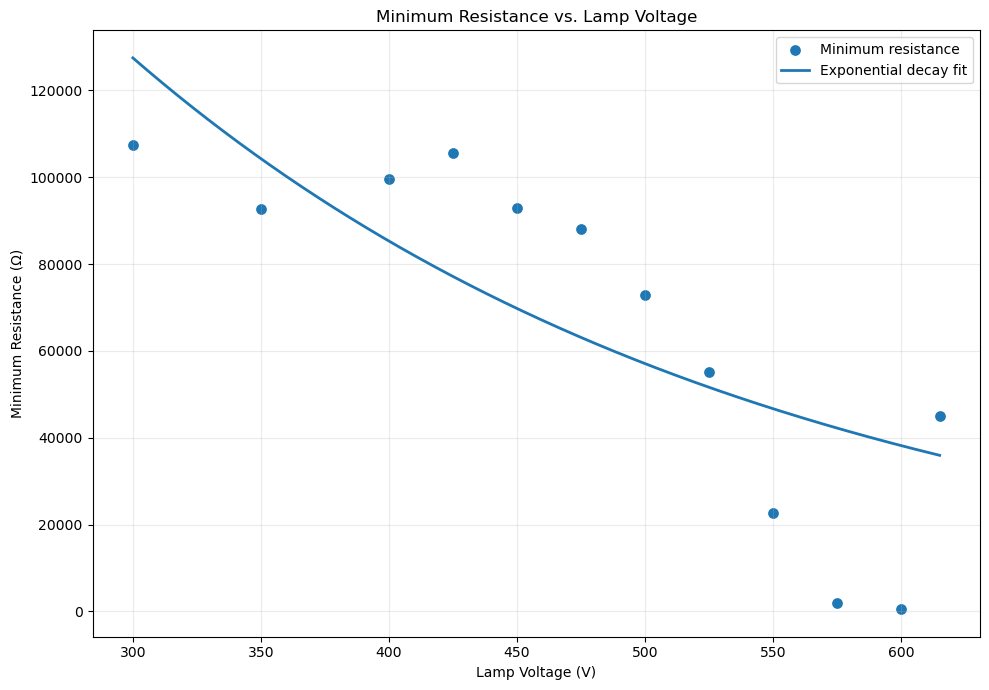

In [361]:
#failed exponential decay fit
# ============================================================
# Minimum Resistance vs. Lamp Voltage
# Exponential Decay Fit with Decreasing Slope
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ------------------------------------------------------------
# Get minimum resistance for each lamp voltage
# ------------------------------------------------------------

voltages = []
min_resistances = []

for lamp, lamp_data in data.items():

    resistance = lamp_data["Resistance (Ω)"].to_numpy()

    # Remove NaN / infinite values
    resistance = resistance[np.isfinite(resistance)]

    if len(resistance) == 0:
        continue

    R_min = np.min(resistance)

    if R_min > 0:
        voltages.append(float(lamp))
        min_resistances.append(float(R_min))


# Convert to arrays
voltages = np.array(voltages)
min_resistances = np.array(min_resistances)

# Sort by voltage
sort_index = np.argsort(voltages)

voltages = voltages[sort_index]
min_resistances = min_resistances[sort_index]


# ------------------------------------------------------------
# Exponential decay model
#
# R(V) = R_offset + A * exp(-V / V0)
# ------------------------------------------------------------

def exponential_decay(V, A, V0, R_offset):
    return R_offset + A * np.exp(-V / V0)


# ------------------------------------------------------------
# Initial guesses
# ------------------------------------------------------------

R_offset_guess = np.min(min_resistances)

A_guess = np.max(min_resistances) - R_offset_guess

V0_guess = 100.0

p0 = [
    A_guess,
    V0_guess,
    R_offset_guess
]


# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------

popt, pcov = curve_fit(
    exponential_decay,
    voltages,
    min_resistances,
    p0=p0,
    bounds=(
        [0, 1e-6, 0],
        [np.inf, np.inf, np.inf]
    ),
    maxfev=100000
)

A_fit, V0_fit, R_offset_fit = popt


# ------------------------------------------------------------
# Generate smooth fitted curve
# ------------------------------------------------------------

voltage_fit = np.linspace(
    voltages.min(),
    voltages.max(),
    1000
)

resistance_fit = exponential_decay(
    voltage_fit,
    A_fit,
    V0_fit,
    R_offset_fit
)


# ------------------------------------------------------------
# Calculate R²
# ------------------------------------------------------------

resistance_predicted = exponential_decay(
    voltages,
    A_fit,
    V0_fit,
    R_offset_fit
)

ss_res = np.sum(
    (min_resistances - resistance_predicted) ** 2
)

ss_tot = np.sum(
    (min_resistances - np.mean(min_resistances)) ** 2
)

R_squared = 1 - ss_res / ss_tot


# ------------------------------------------------------------
# Print fit parameters
# ------------------------------------------------------------

print("Exponential Decay Fit")
print("==============================")

print(
    "R(V) = R_offset + A * exp(-V / V0)"
)

print(f"A        = {A_fit:.6g} Ω")
print(f"V0       = {V0_fit:.6g} V")
print(f"R_offset = {R_offset_fit:.6g} Ω")
print(f"R²       = {R_squared:.6f}")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

# Experimental data
ax.scatter(
    voltages,
    min_resistances,
    s=45,
    label="Minimum resistance"
)

# Exponential fit
ax.plot(
    voltage_fit,
    resistance_fit,
    linewidth=2,
    label="Exponential decay fit"
)

ax.set_xlabel("Lamp Voltage (V)")
ax.set_ylabel("Minimum Resistance (Ω)")
ax.set_title("Minimum Resistance vs. Lamp Voltage")

# IMPORTANT:
# Linear y-axis so exponential curvature is visible
ax.set_yscale("linear")

ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## fit decay models on current!

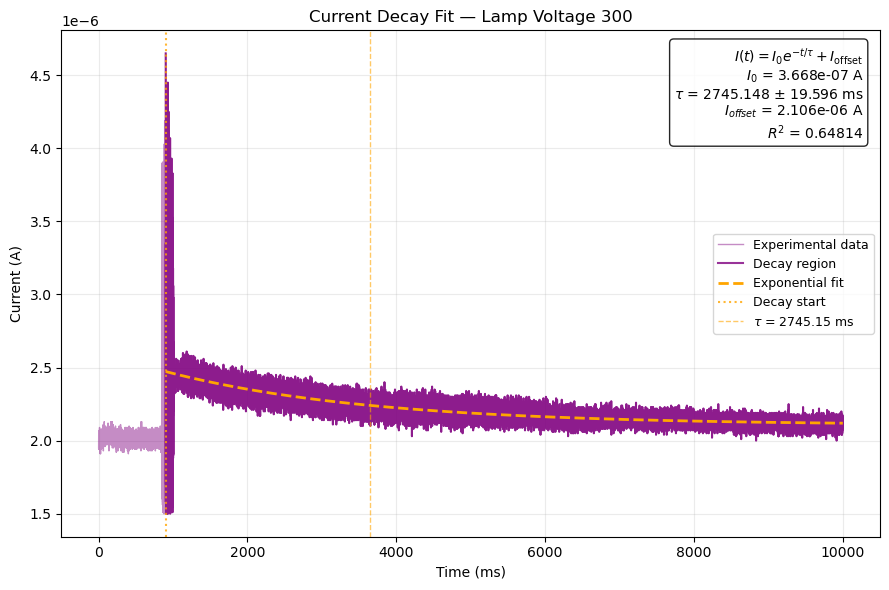

Lamp 300: peak = 901.400 ms, tau = 2745.148 ± 19.596 ms, R² = 0.64814


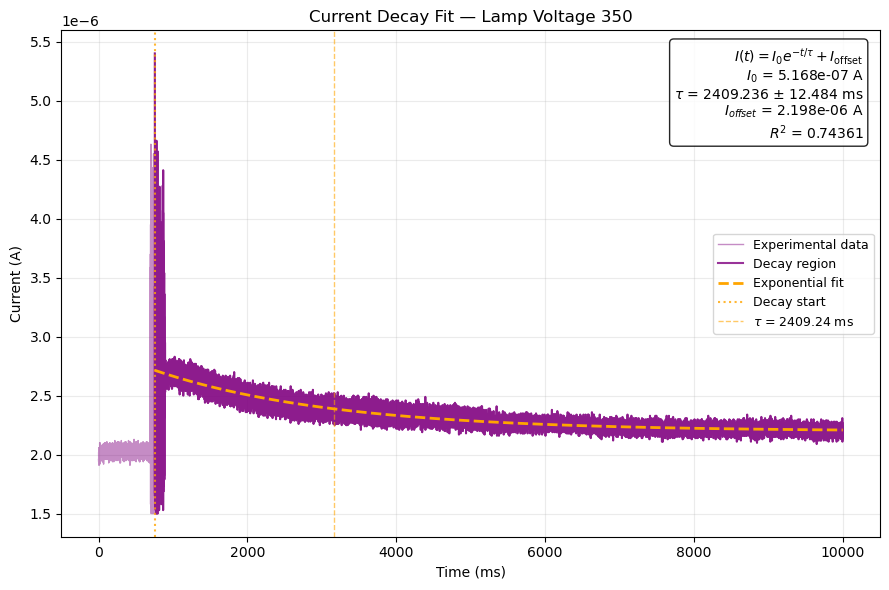

Lamp 350: peak = 755.000 ms, tau = 2409.236 ± 12.484 ms, R² = 0.74361


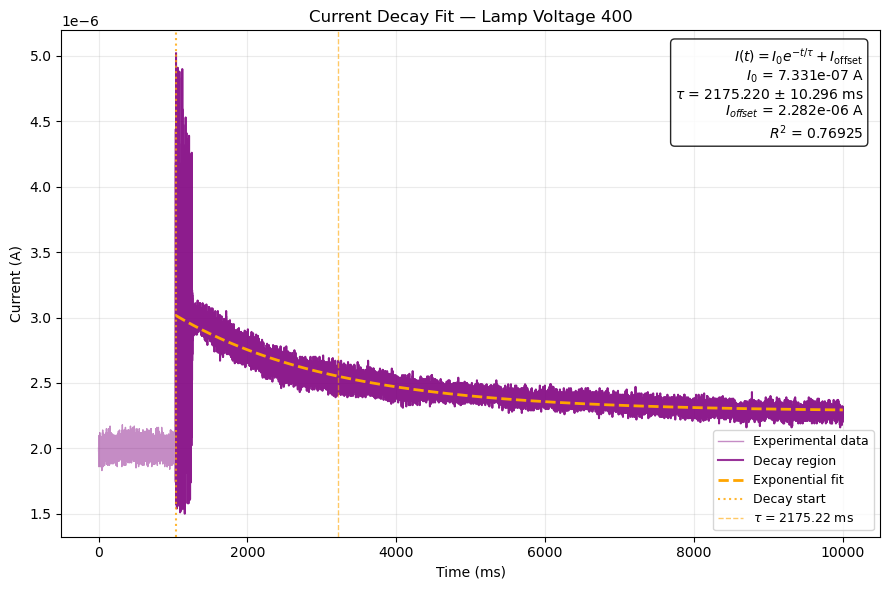

Lamp 400: peak = 1040.500 ms, tau = 2175.220 ± 10.296 ms, R² = 0.76925


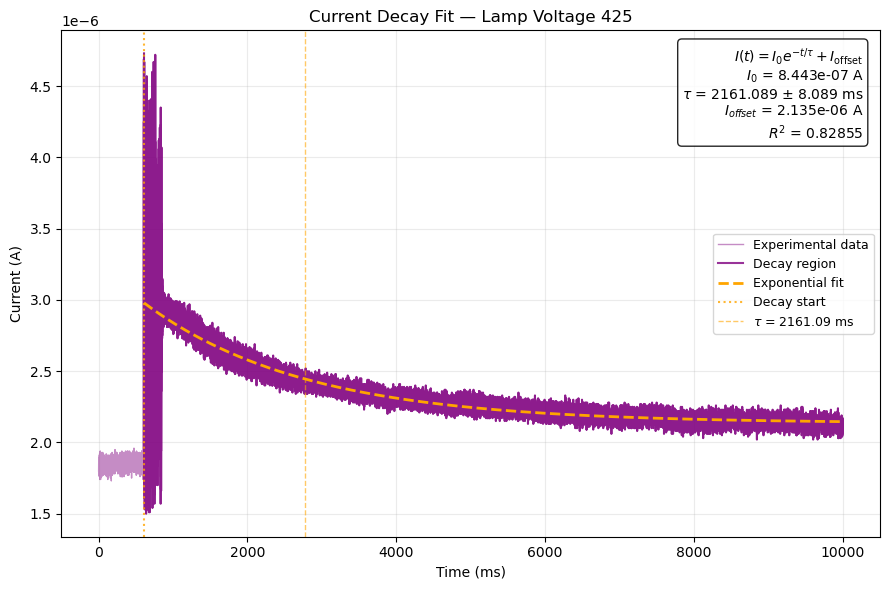

Lamp 425: peak = 610.100 ms, tau = 2161.089 ± 8.089 ms, R² = 0.82855


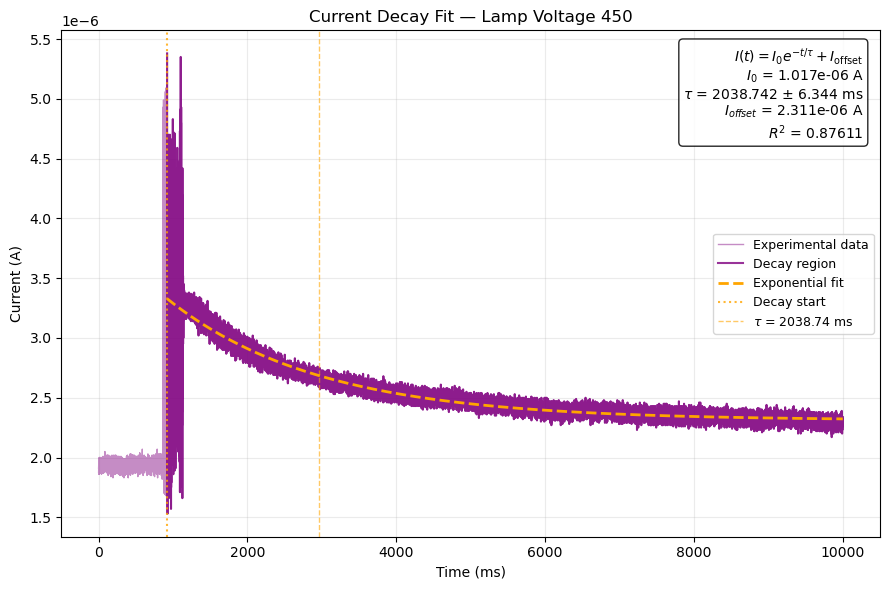

Lamp 450: peak = 920.800 ms, tau = 2038.742 ± 6.344 ms, R² = 0.87611


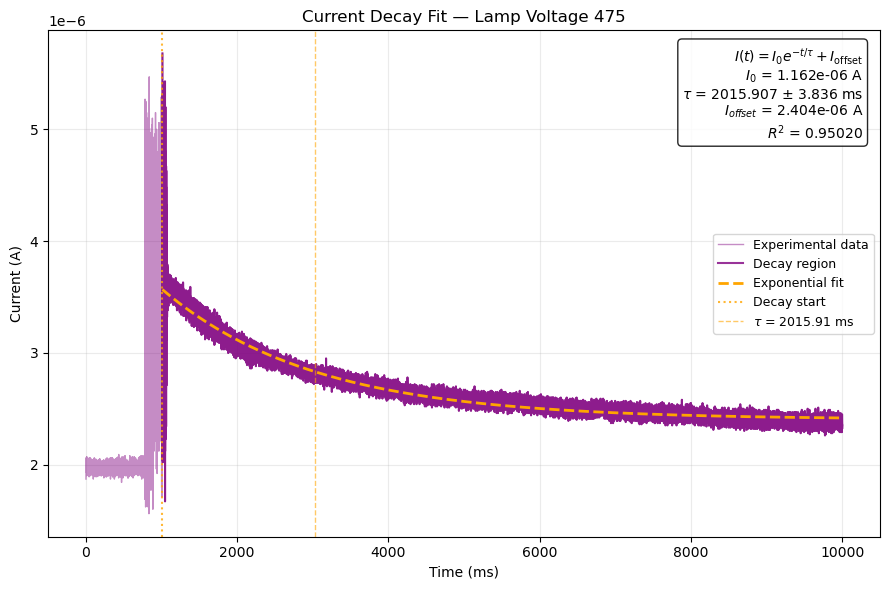

Lamp 475: peak = 1011.400 ms, tau = 2015.907 ± 3.836 ms, R² = 0.95020


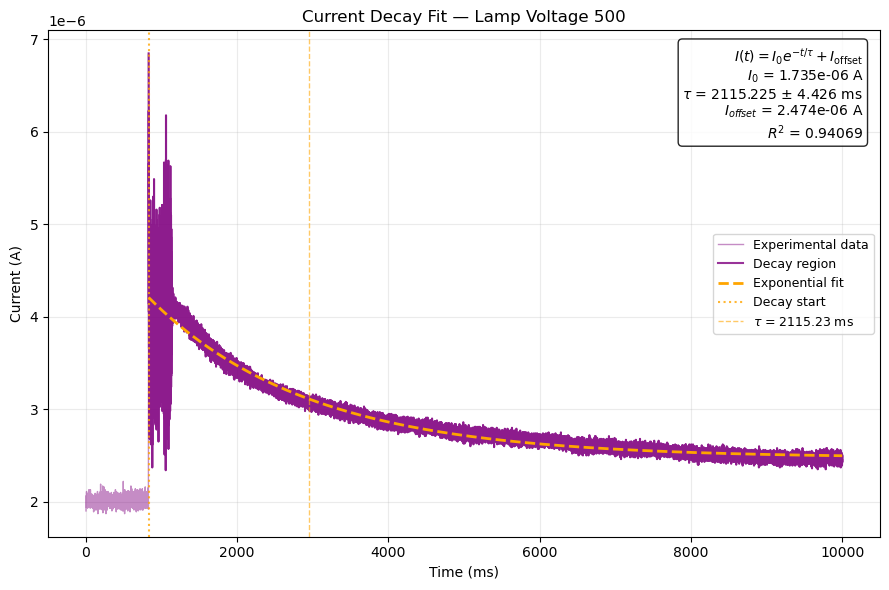

Lamp 500: peak = 828.600 ms, tau = 2115.225 ± 4.426 ms, R² = 0.94069


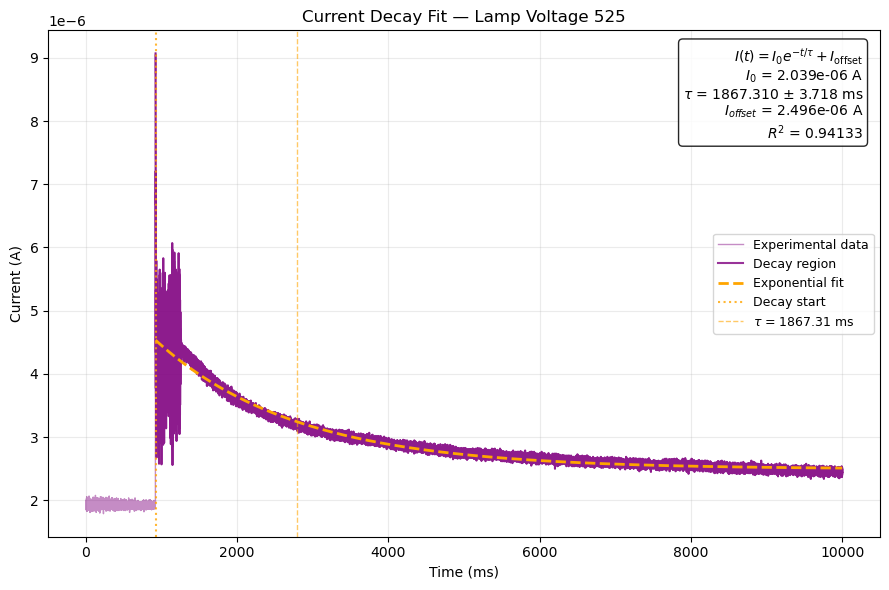

Lamp 525: peak = 920.300 ms, tau = 1867.310 ± 3.718 ms, R² = 0.94133


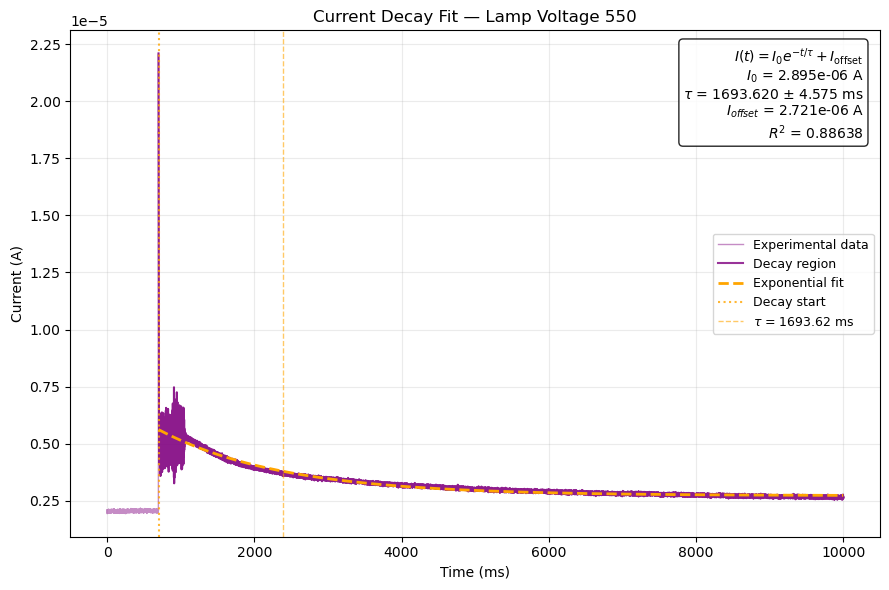

Lamp 550: peak = 698.700 ms, tau = 1693.620 ± 4.575 ms, R² = 0.88638


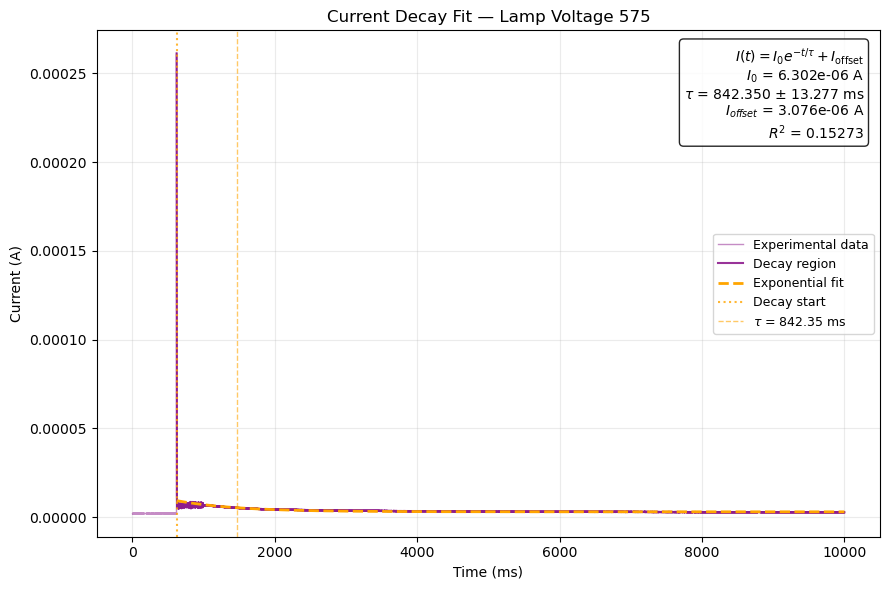

Lamp 575: peak = 619.700 ms, tau = 842.350 ± 13.277 ms, R² = 0.15273


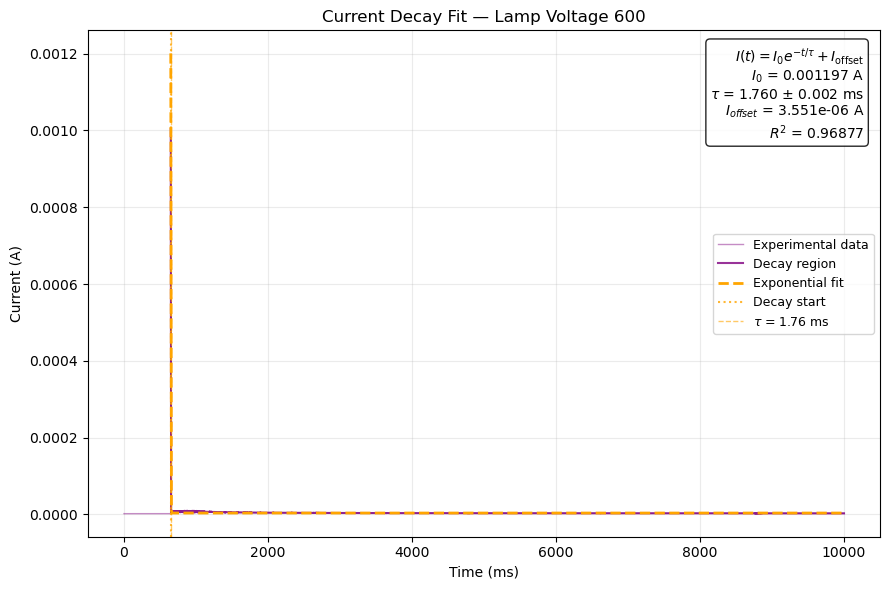

Lamp 600: peak = 649.200 ms, tau = 1.760 ± 0.002 ms, R² = 0.96877


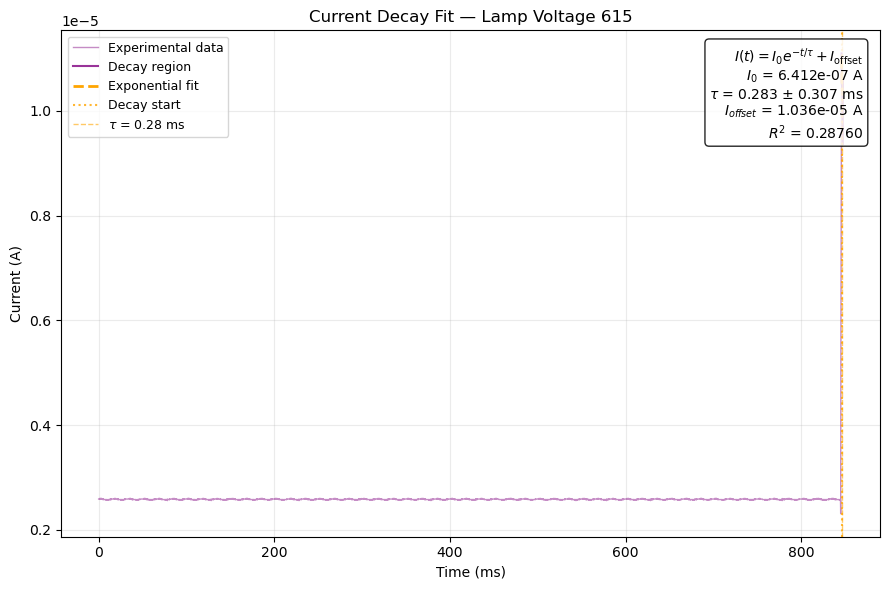

Lamp 615: peak = 845.900 ms, tau = 0.283 ± 0.307 ms, R² = 0.28760

Current Decay Characterization:
 Lamp       I0 (A)  Tau (s)    Tau (ms)  Tau uncertainty (ms)  Half-life (ms)    t90 (ms)  I offset (A)       R²
  300 3.667789e-07 2.745148 2745.148041             19.596339     1902.791625 6320.936958      0.000002 0.648143
  350 5.168346e-07 2.409236 2409.236479             12.484157     1669.955472 5547.472001      0.000002 0.743612
  400 7.330670e-07 2.175220 2175.219565             10.295986     1507.747309 5008.628145      0.000002 0.769251
  425 8.442868e-07 2.161089 2161.088968              8.089403     1497.952725 4976.091243      0.000002 0.828554
  450 1.016930e-06 2.038742 2038.741809              6.343506     1413.148137 4694.376498      0.000002 0.876111
  475 1.162329e-06 2.015907 2015.906936              3.835634     1397.320209 4641.797260      0.000002 0.950201
  500 1.734902e-06 2.115225 2115.225024              4.425804     1466.162261 4870.485608      0.000002 0.9406

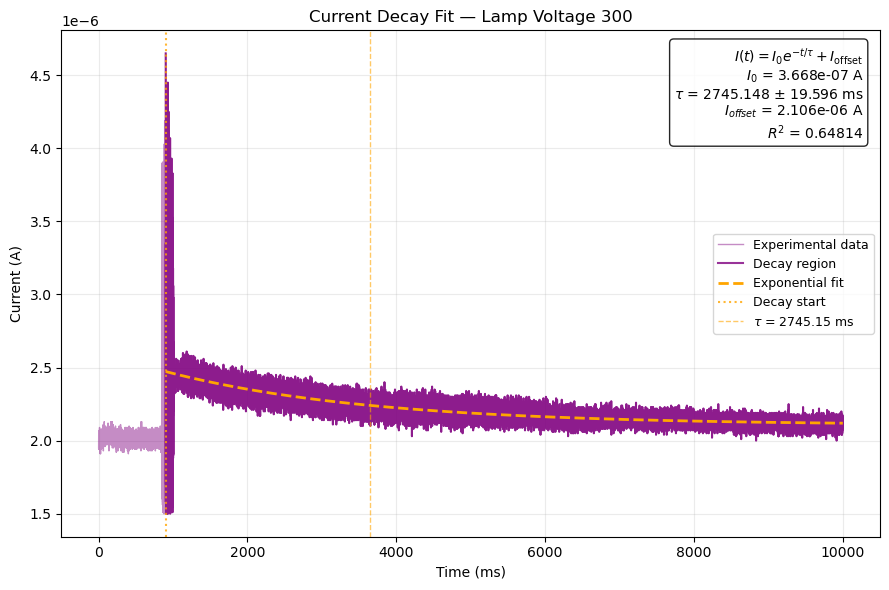

Lamp 300: peak = 901.400 ms, tau = 2745.148 ± 19.596 ms, R² = 0.64814


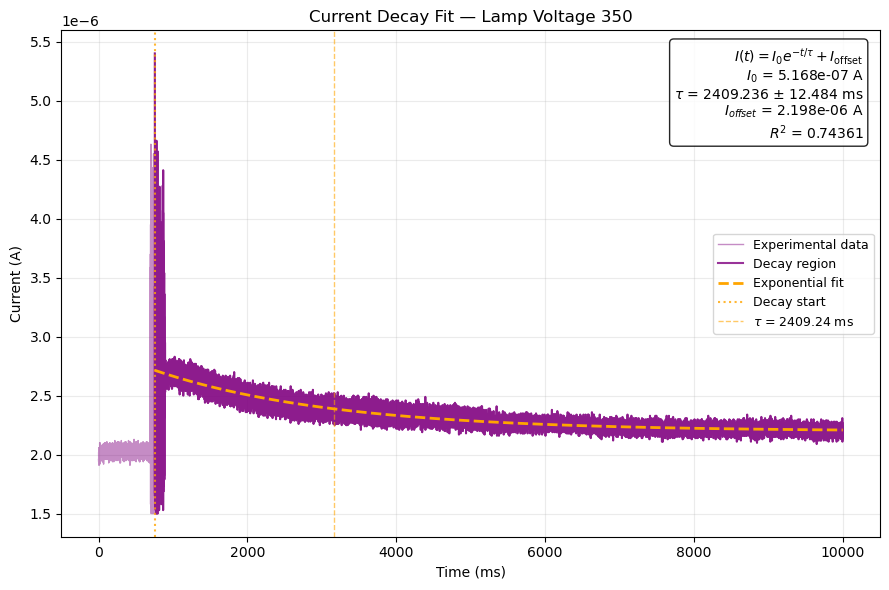

Lamp 350: peak = 755.000 ms, tau = 2409.236 ± 12.484 ms, R² = 0.74361


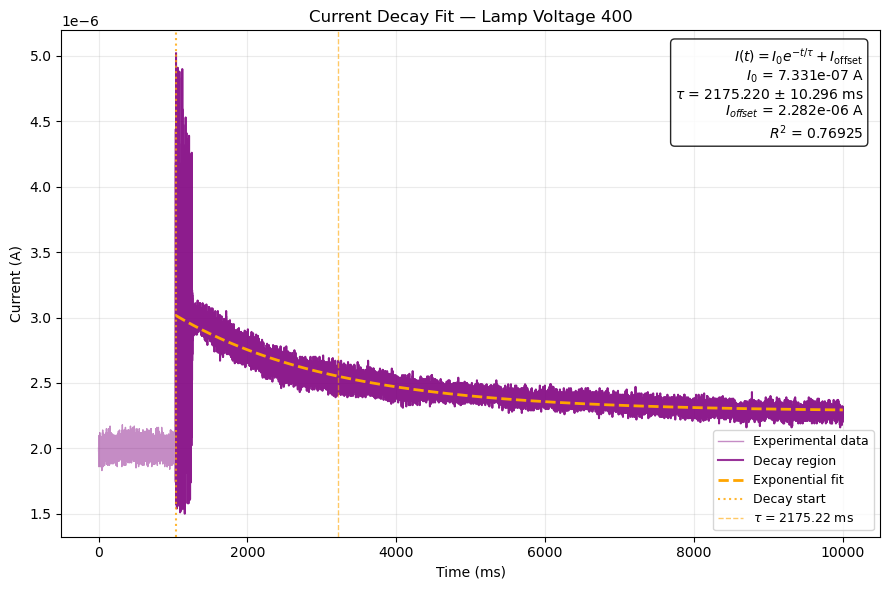

Lamp 400: peak = 1040.500 ms, tau = 2175.220 ± 10.296 ms, R² = 0.76925


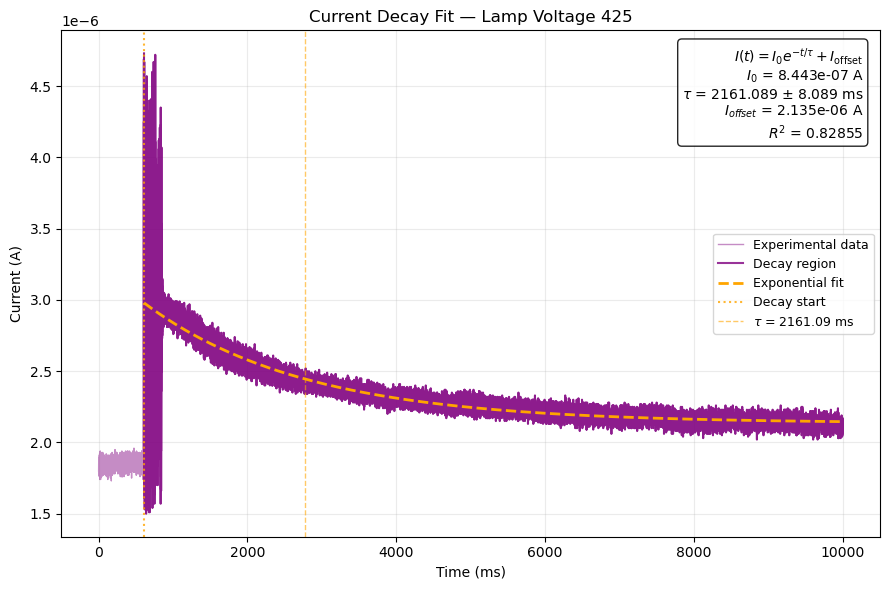

Lamp 425: peak = 610.100 ms, tau = 2161.089 ± 8.089 ms, R² = 0.82855


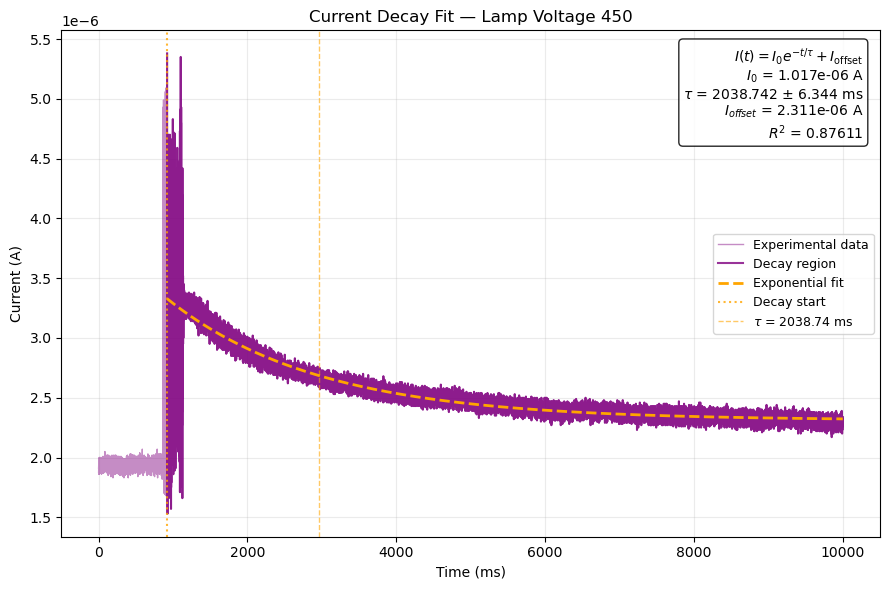

Lamp 450: peak = 920.800 ms, tau = 2038.742 ± 6.344 ms, R² = 0.87611


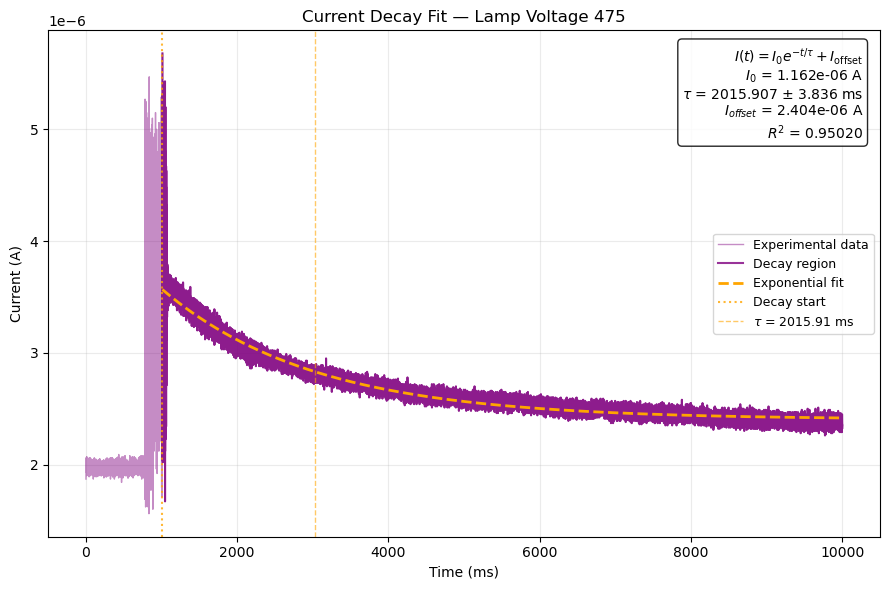

Lamp 475: peak = 1011.400 ms, tau = 2015.907 ± 3.836 ms, R² = 0.95020


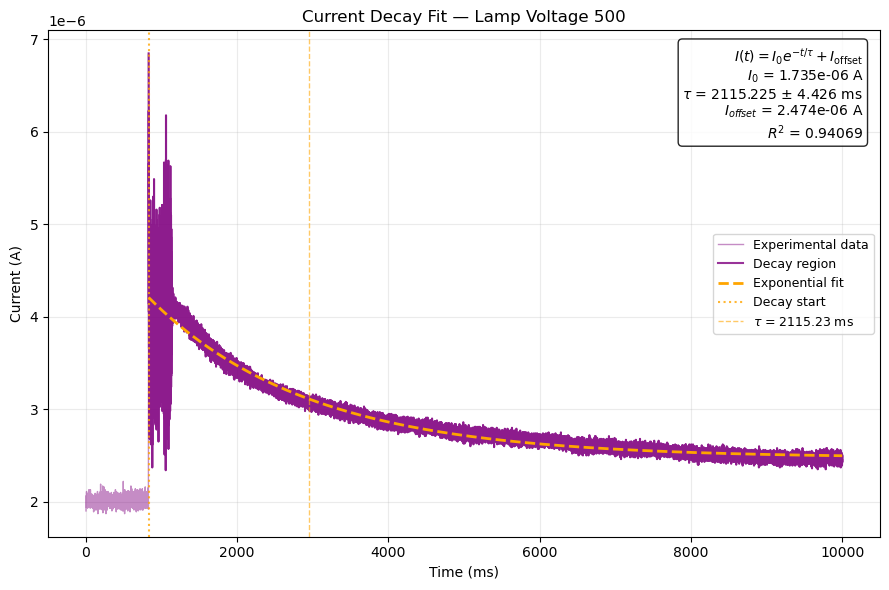

Lamp 500: peak = 828.600 ms, tau = 2115.225 ± 4.426 ms, R² = 0.94069


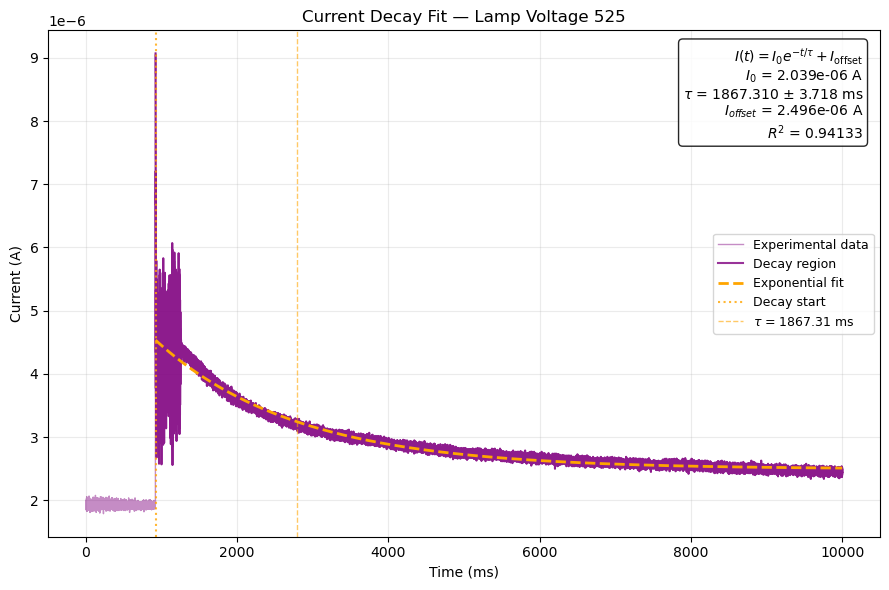

Lamp 525: peak = 920.300 ms, tau = 1867.310 ± 3.718 ms, R² = 0.94133


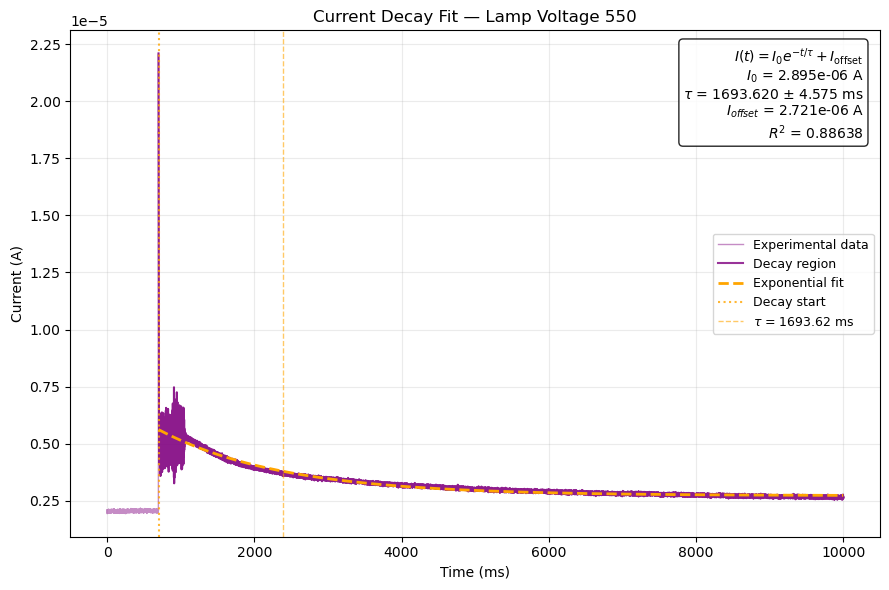

Lamp 550: peak = 698.700 ms, tau = 1693.620 ± 4.575 ms, R² = 0.88638


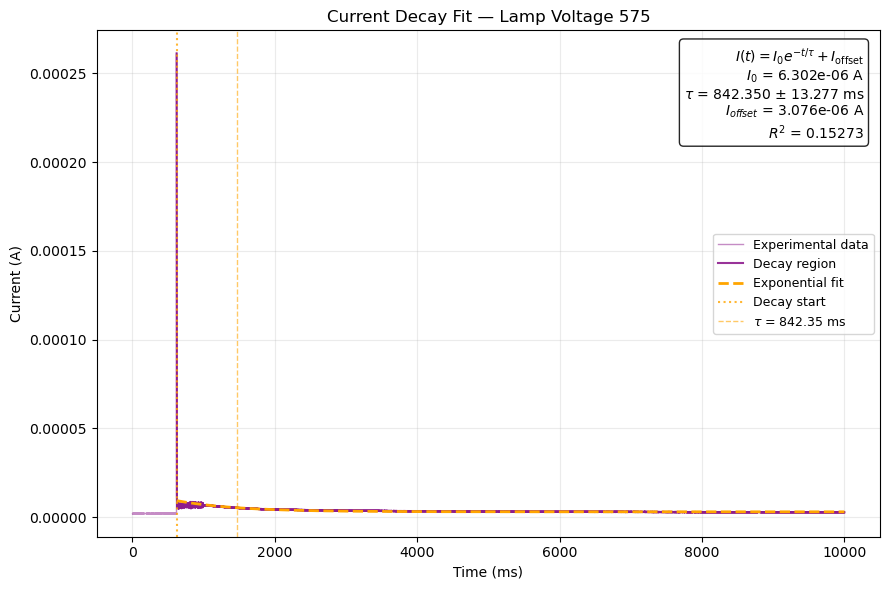

Lamp 575: peak = 619.700 ms, tau = 842.350 ± 13.277 ms, R² = 0.15273


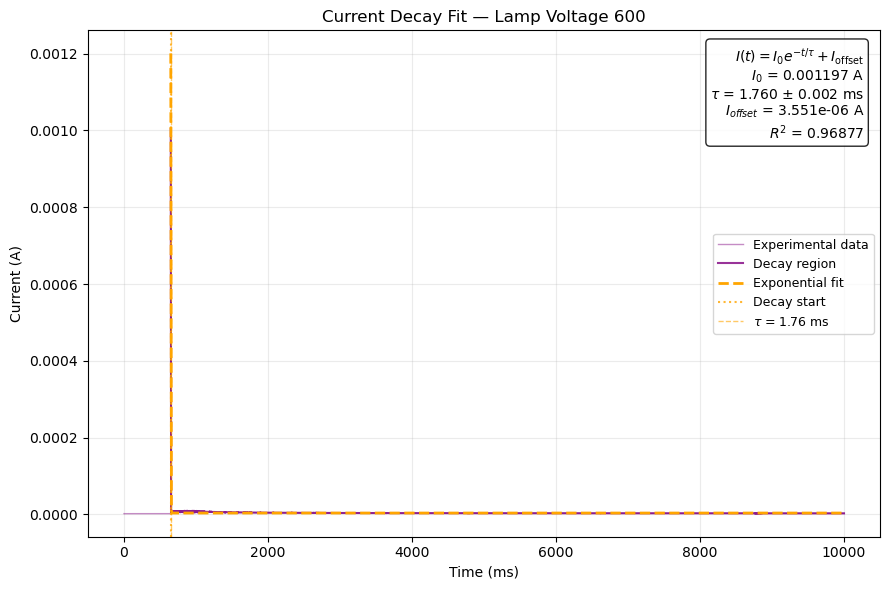

Lamp 600: peak = 649.200 ms, tau = 1.760 ± 0.002 ms, R² = 0.96877


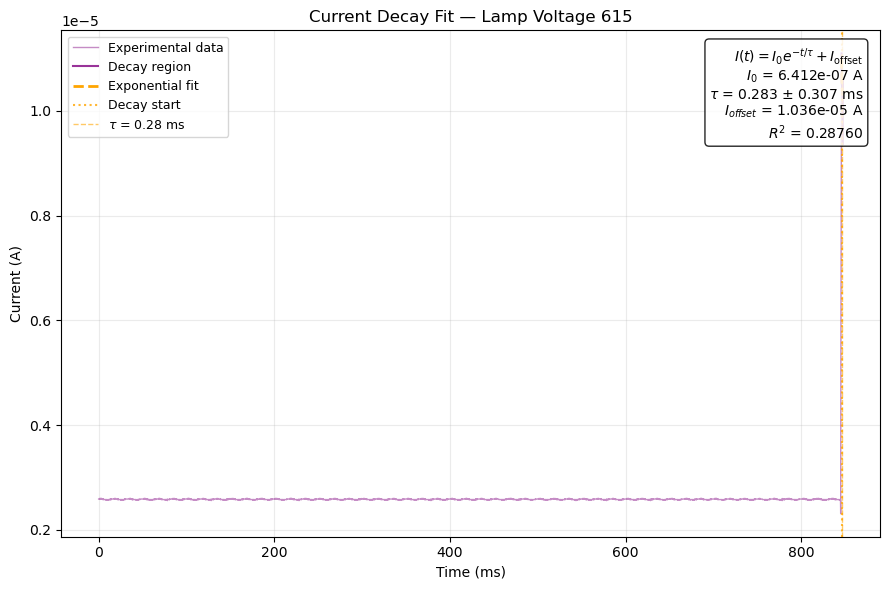

Lamp 615: peak = 845.900 ms, tau = 0.283 ± 0.307 ms, R² = 0.28760

Current Decay Characterization:
 Lamp       I0 (A)  Tau (s)    Tau (ms)  Tau uncertainty (ms)  Half-life (ms)    t90 (ms)  I offset (A)       R²
  300 3.667789e-07 2.745148 2745.148041             19.596339     1902.791625 6320.936958      0.000002 0.648143
  350 5.168346e-07 2.409236 2409.236479             12.484157     1669.955472 5547.472001      0.000002 0.743612
  400 7.330670e-07 2.175220 2175.219565             10.295986     1507.747309 5008.628145      0.000002 0.769251
  425 8.442868e-07 2.161089 2161.088968              8.089403     1497.952725 4976.091243      0.000002 0.828554
  450 1.016930e-06 2.038742 2038.741809              6.343506     1413.148137 4694.376498      0.000002 0.876111
  475 1.162329e-06 2.015907 2015.906936              3.835634     1397.320209 4641.797260      0.000002 0.950201
  500 1.734902e-06 2.115225 2115.225024              4.425804     1466.162261 4870.485608      0.000002 0.9406

In [362]:
# Fit current decay curves and characterize decay time
# ============================================================
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd


def exponential_decay(t, I0, tau, I_offset):
    """
    Exponential current decay:
        I(t) = I0 * exp(-t/tau) + I_offset
    """
    return I0 * np.exp(-t / tau) + I_offset


def fit_current_decay(time, current):
    """
    Fit the current decay starting at the maximum-current spike.

    The maximum current is identified as the beginning of the decay.
    The fitting time is shifted so that the spike occurs at t = 0.
    """

    time = np.asarray(time, dtype=float)
    current = np.asarray(current, dtype=float)

    # ------------------------------------------------------------
    # Remove NaN / infinite values
    # ------------------------------------------------------------

    mask = np.isfinite(time) & np.isfinite(current)
    time = time[mask]
    current = current[mask]

    # ------------------------------------------------------------
    # Find the current spike
    # ------------------------------------------------------------

    peak_index = np.argmax(current)

    # Time and current starting at the spike
    time_decay = time[peak_index:]
    current_decay = current[peak_index:]

    # Original time axis for plotting
    time_decay_original = time_decay.copy()

    # Shift time so that the current spike occurs at t = 0
    time_fit = time_decay - time_decay[0]

    # ------------------------------------------------------------
    # Initial guesses
    # ------------------------------------------------------------

    # Estimate baseline from the final 10% of the decay
    n_tail = max(5, len(current_decay) // 10)

    I_offset_guess = np.mean(current_decay[-n_tail:])

    # Initial amplitude
    I0_guess = current_decay[0] - I_offset_guess

    # Estimate tau from the decay duration
    tau_guess = (time_fit[-1] - time_fit[0]) / 5
    tau_guess = max(tau_guess, 1e-9)

    p0 = [
        I0_guess,
        tau_guess,
        I_offset_guess
    ]

    # ------------------------------------------------------------
    # Exponential fit
    # ------------------------------------------------------------

    bounds = (
        [-np.inf, 1e-12, -np.inf],
        [np.inf, np.inf, np.inf]
    )

    popt, pcov = curve_fit(
        exponential_decay,
        time_fit,
        current_decay,
        p0=p0,
        bounds=bounds,
        maxfev=50000
    )

    I0_fit, tau_fit, I_offset_fit = popt

    # ------------------------------------------------------------
    # Calculate fitted curve
    # ------------------------------------------------------------

    current_fit = exponential_decay(
        time_fit,
        I0_fit,
        tau_fit,
        I_offset_fit
    )

    # ------------------------------------------------------------
    # R²
    # ------------------------------------------------------------

    residuals = current_decay - current_fit

    ss_res = np.sum(residuals**2)

    ss_tot = np.sum(
        (current_decay - np.mean(current_decay))**2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    # ------------------------------------------------------------
    # Return results
    # ------------------------------------------------------------

    return (
        time_fit,              # shifted time for fitting
        time_decay_original,   # original time for plotting
        current_decay,         # decay data only
        current_fit,           # fitted decay
        popt,                  # [I0, tau, I_offset]
        pcov,                  # covariance matrix
        r2,                    # R²
        peak_index             # index of current spike
    )

def characterize_current_decays(data):
    """
    Fit every current decay curve and create a separate plot
    for each lamp setting.

    The exponential fit begins at the maximum-current spike.
    """

    results = []

    for lamp, lamp_data in data.items():

        time = lamp_data["Time (s)"].to_numpy()
        current = lamp_data["Current (A)"].to_numpy()

        try:

            # ----------------------------------------------------
            # Fit decay
            # ----------------------------------------------------

            (
                time_fit,
                time_decay_original,
                current_clean,
                current_model,
                popt,
                pcov,
                r2,
                peak_index
            ) = fit_current_decay(time, current)

            I0, tau, I_offset = popt

            # ----------------------------------------------------
            # Uncertainty in tau
            # ----------------------------------------------------

            tau_uncertainty = np.sqrt(pcov[1, 1])

            # Characteristic times
            half_life = tau * np.log(2)
            t90 = tau * np.log(10)

            # ----------------------------------------------------
            # Store results
            # ----------------------------------------------------

            results.append({
                "Lamp": lamp,
                "I0 (A)": I0,
                "Tau (s)": tau,
                "Tau (ms)": tau * 1e3,
                "Tau uncertainty (ms)": tau_uncertainty * 1e3,
                "Half-life (ms)": half_life * 1e3,
                "t90 (ms)": t90 * 1e3,
                "I offset (A)": I_offset,
                "R²": r2
            })

            # ----------------------------------------------------
            # Create individual plot
            # ----------------------------------------------------

            fig, ax = plt.subplots(figsize=(9, 6))

            # Plot ALL experimental data
            ax.plot(
                time * 1e3,
                current,
                linewidth=1.0,
                alpha=0.45,
                label="Experimental data",
                color = "purple",
            )

            # Plot only the portion used for the fit
            ax.plot(
                time_decay_original * 1e3,
                current_clean,
                linewidth=1.5,
                label="Decay region",
                color = "purple",
                alpha = 0.8
            )

            # ----------------------------------------------------
            # Smooth exponential fit
            # ----------------------------------------------------

            time_smooth = np.linspace(
                time_fit.min(),
                time_fit.max(),
                1000
            )

            current_smooth = exponential_decay(
                time_smooth,
                I0,
                tau,
                I_offset
            )

            # Convert shifted fit time back to original time
            time_smooth_original = (
                time_smooth + time_decay_original[0]
            )

            ax.plot(
                time_smooth_original * 1e3,
                current_smooth,
                "--",
                linewidth=2,
                label="Exponential fit",
                color = "orange"
            )

            # ----------------------------------------------------
            # Mark the current spike / fit start
            # ----------------------------------------------------

            peak_time = time[peak_index]

            ax.axvline(
                peak_time * 1e3,
                linestyle=":",
                linewidth=1.5,
                alpha=0.8,
                label="Decay start",
                color = "orange"
            )

            # ----------------------------------------------------
            # Mark tau
            # ----------------------------------------------------

            tau_time = peak_time + tau

            ax.axvline(
                tau_time * 1e3,
                linestyle="--",
                linewidth=1.0,
                alpha=0.6,
                label=fr"$\tau$ = {tau*1e3:.2f} ms",
                color = "orange"
            )

            # ----------------------------------------------------
            # Fit information
            # ----------------------------------------------------

            fit_text = (
                r"$I(t)=I_0e^{-t/\tau}+I_{\mathrm{offset}}$" "\n"
                f"$I_0$ = {I0:.4g} A\n"
                f"$\\tau$ = {tau*1e3:.3f} ± "
                f"{tau_uncertainty*1e3:.3f} ms\n"
                f"$I_{{offset}}$ = {I_offset:.4g} A\n"
                f"$R^2$ = {r2:.5f}"
            )

            ax.text(
                0.98,
                0.97,
                fit_text,
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment="top",
                horizontalalignment="right",
                bbox=dict(
                    boxstyle="round",
                    facecolor="white",
                    alpha=0.85
                )
            )

            # ----------------------------------------------------
            # Labels / formatting
            # ----------------------------------------------------

            ax.set_xlabel("Time (ms)")
            ax.set_ylabel("Current (A)")
            ax.set_title(
                f"Current Decay Fit — Lamp Voltage {lamp}"
            )

            ax.grid(True, alpha=0.25)
            ax.legend(loc="best", fontsize=9)

            fig.tight_layout()

            # ----------------------------------------------------
            # Save individual plot
            # ----------------------------------------------------

            # filename = f"current_decay_fit_lamp_{lamp}.png"

            # fig.savefig(
            #     filename,
            #     dpi=300,
            #     bbox_inches="tight"
            # )

            plt.show()
            plt.close(fig)

            print(
                f"Lamp {lamp}: "
                f"peak = {peak_time*1e3:.3f} ms, "
                f"tau = {tau*1e3:.3f} ± "
                f"{tau_uncertainty*1e3:.3f} ms, "
                f"R² = {r2:.5f}"
            )

        except Exception as e:
            print(f"Could not fit lamp {lamp}: {e}")

    return pd.DataFrame(results)


# ============================================================
# Run characterization
# ============================================================

decay_results = characterize_current_decays(data)

print("\nCurrent Decay Characterization:")
print(decay_results.to_string(index=False))


# ============================================================
# Run characterization
# ============================================================

decay_results = characterize_current_decays(data)

print("\nCurrent Decay Characterization:")
print(decay_results.to_string(index=False))

## more 575


Lamp 575 V:
Resistance at 5 s: 154320.99 Ω
Closest measured time: 5.000000 s


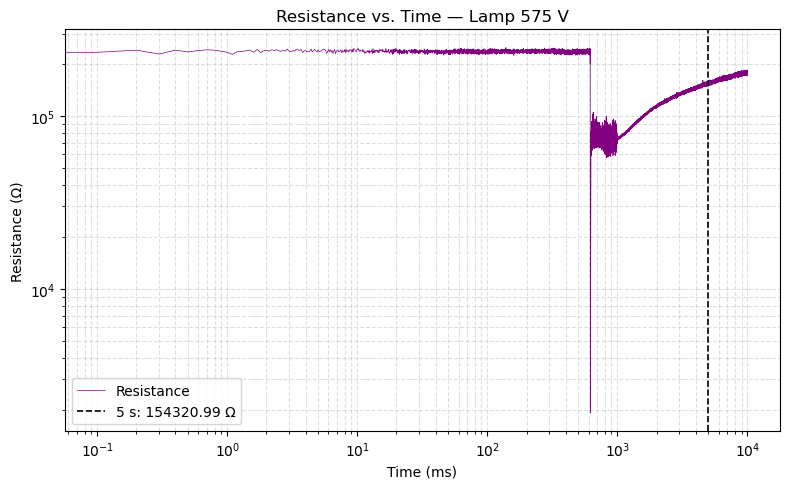

In [363]:
# ============================================================
# 575 V Resistance vs. Time — Log Scale
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

lamp = 575

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find the measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.5,
    label="Resistance",
    c="purple"
)

# Vertical line at 5 seconds = 5000 ms
plt.axvline(
    x=5000,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"5 s: {resistance_at_5s:.2f} Ω"
)

#plt.xlim(0, 10000)  # Limit x-axis to 10 seconds (10000 ms)

# Logarithmic y-axis
plt.yscale("log")
plt.xscale("log")

# Labels and title
plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title("Resistance vs. Time — Lamp 575 V")

# Grid
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

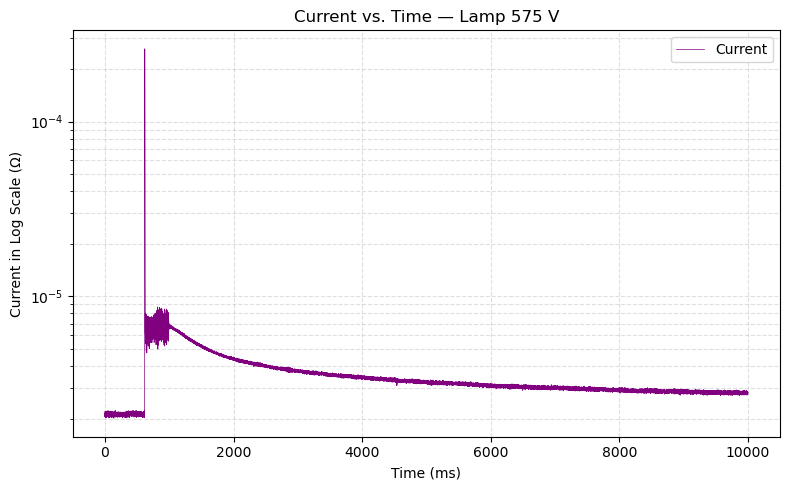

In [364]:
# 575 V Current vs. Time — Log Scale
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

lamp = 575

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
current = lamp_data["Current (A)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(current)
    & (current > 0)   # Required for log scale
)

time = time[mask]
current = current[mask]

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    current,
    linewidth=0.5,
    label="Current",
    c = "purple"
)

# Logarithmic y-axis
plt.yscale("log")


# Labels and title
plt.xlabel("Time (ms)")
plt.ylabel("Current in Log Scale (Ω)")
plt.title("Current vs. Time — Lamp 575 V")

# Grid
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

## detailed graph fits?

Lamp 575 V:
Resistance at 5 s: 154320.99 Ω
Closest measured time: 5.000000 s
REACHED PLOT


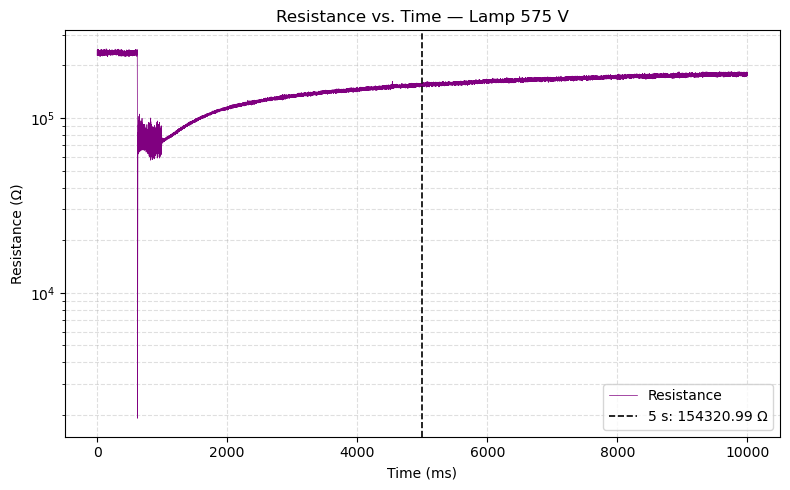

In [365]:
#575 log
# import matplotlib.pyplot as plt
# import numpy as np

lamp = 575

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find the measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
print("REACHED PLOT")
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.5,
    label="Resistance",
    c="purple"
)

# Vertical line at 5 seconds = 5000 ms
plt.axvline(
    x=5000,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"5 s: {resistance_at_5s:.2f} Ω"
)

#plt.xlim(0, 10000)  # Limit x-axis to 10 seconds (10000 ms)

# Logarithmic y-axis
plt.yscale("log")
#plt.xscale("log")

# Labels and title
plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title("Resistance vs. Time — Lamp 575 V")

# Grid
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

### study specifics 575

Lamp 575 V:
Resistance at 5 s: 154320.99 Ω
Closest measured time: 5.000000 s
REACHED PLOT


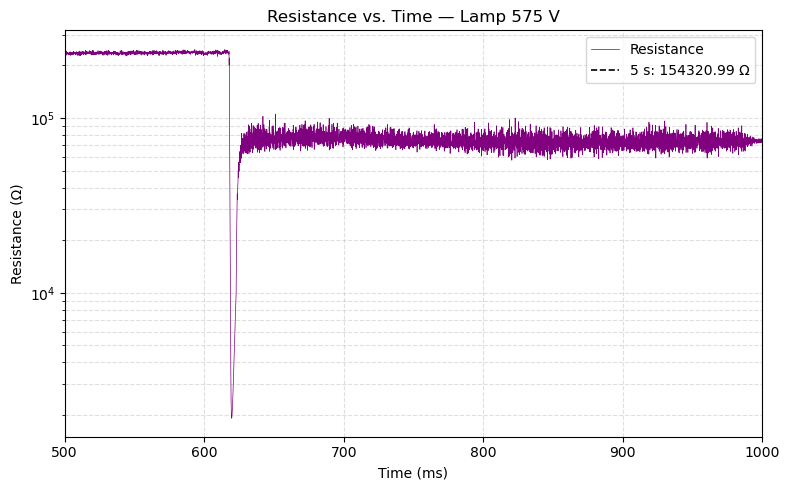

In [366]:
#575 log log
# import matplotlib.pyplot as plt
# import numpy as np

lamp = 575

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find the measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
print("REACHED PLOT")
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.5,
    label="Resistance",
    c="purple"
)

# Vertical line at 5 seconds = 5000 ms
plt.axvline(
    x=5000,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"5 s: {resistance_at_5s:.2f} Ω"
)

plt.xlim(500, 1000)  # Limit x-axis to 10 seconds (10000 ms)

# Logarithmic y-axis
plt.yscale("log")
# plt.xscale("log")

# Labels and title
plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title("Resistance vs. Time — Lamp 575 V")

# Grid
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

### 575 log log fitting

Lamp: 575 V
Minimum resistance: 1913.80 Ω
Time of minimum resistance: 0.619700 s
Maximum measured resistance: 248756.22 Ω
Time of maximum measured resistance: 0.138700 s
Number of points used for fit: 93803

The fitted asymptote R_inf is below the maximum measured resistance.
R_inf = 166519.72 Ω
R_max = 248756.22 Ω

Post-minimum exponential recovery fit:
R(t) = 166520 - (166520 - 1913.8) * exp(-0.815352 * (t - 0.6197))

R_inf = 166519.719712 Ω
k = 0.815352 s⁻¹
R² = 0.796124


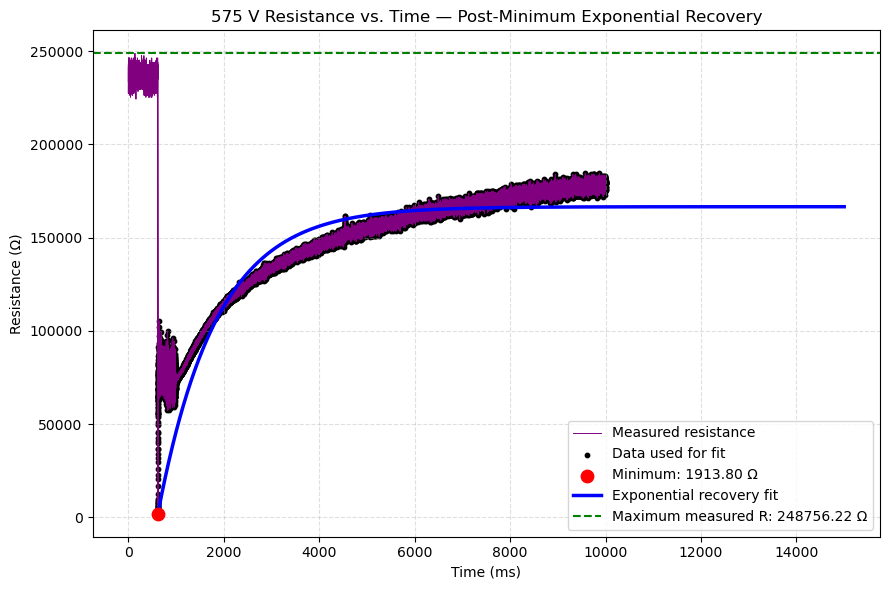

In [367]:
# ============================================================
# 575 V Resistance vs. Time
# Post-Minimum Exponential Fit + Predicted Time to Max Resistance
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

lamp = 575

# ============================================================
# Load data
# ============================================================

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
    & (time > 0)
)

time = time[mask]
resistance = resistance[mask]

# Sort by time
sort_idx = np.argsort(time)

time = time[sort_idx]
resistance = resistance[sort_idx]

# ============================================================
# Find minimum and maximum resistance
# ============================================================

min_index = np.argmin(resistance)

t_min = time[min_index]
R_min = resistance[min_index]

R_max = np.max(resistance)
max_index = np.argmax(resistance)
t_max_measured = time[max_index]

print(f"Lamp: {lamp} V")
print(f"Minimum resistance: {R_min:.2f} Ω")
print(f"Time of minimum resistance: {t_min:.6f} s")
print(f"Maximum measured resistance: {R_max:.2f} Ω")
print(f"Time of maximum measured resistance: {t_max_measured:.6f} s")

# ============================================================
# Data from minimum resistance onwards
# ============================================================

time_fit_data = time[min_index:]
resistance_fit_data = resistance[min_index:]

print(f"Number of points used for fit: {len(time_fit_data)}")

# ============================================================
# Exponential recovery model
#
# R(t) = R_inf - (R_inf - R_min)
#              * exp(-k * (t - t_min))
# ============================================================

def recovery_model(t, R_inf, k):
    return (
        R_inf
        - (R_inf - R_min)
        * np.exp(-k * (t - t_min))
    )

# ============================================================
# Initial guesses
# ============================================================

R_inf_guess = R_max * 1.1
k_guess = 0.5

initial_guess = [
    R_inf_guess,
    k_guess
]

# ============================================================
# Fit
# ============================================================

popt, pcov = curve_fit(
    recovery_model,
    time_fit_data,
    resistance_fit_data,
    p0=initial_guess,
    bounds=(
        [R_min, 0],
        [np.inf, np.inf]
    ),
    maxfev=100000
)

R_inf, k = popt

# ============================================================
# Calculate R²
# ============================================================

R_pred = recovery_model(
    time_fit_data,
    R_inf,
    k
)

ss_res = np.sum(
    (resistance_fit_data - R_pred) ** 2
)

ss_tot = np.sum(
    (resistance_fit_data - np.mean(resistance_fit_data)) ** 2
)

r_squared = 1 - ss_res / ss_tot

# ============================================================
# Find predicted time when fit reaches maximum resistance
#
# R_max = R_inf - (R_inf - R_min)*exp(-k*(t-t_min))
#
# Solve for t:
#
# t = t_min -
#     ln((R_inf-R_max)/(R_inf-R_min)) / k
# ============================================================

if R_max < R_inf:

    t_at_Rmax = (
        t_min
        - np.log(
            (R_inf - R_max)
            / (R_inf - R_min)
        ) / k
    )

    print("\nPredicted maximum-resistance crossing:")
    print(f"R_max = {R_max:.2f} Ω")
    print(f"Predicted time = {t_at_Rmax:.6f} s")
    print(f"Predicted time = {t_at_Rmax * 1e3:.2f} ms")

    # Check predicted resistance
    R_check = recovery_model(t_at_Rmax, R_inf, k)

    print(f"Fit resistance at that time = {R_check:.2f} Ω")

else:

    t_at_Rmax = None

    print(
        "\nThe fitted asymptote R_inf is below "
        "the maximum measured resistance."
    )
    print(f"R_inf = {R_inf:.2f} Ω")
    print(f"R_max = {R_max:.2f} Ω")

# ============================================================
# Generate extended fitted curve
# ============================================================

if t_at_Rmax is not None:

    # Extend curve slightly past crossing
    t_end = t_at_Rmax * 1.05

else:

    # If max resistance cannot be reached,
    # extend by 50% beyond measured range
    t_end = time_fit_data.max() * 1.5

t_smooth = np.logspace(
    np.log10(time_fit_data.min()),
    np.log10(t_end),
    800
)

R_smooth = recovery_model(
    t_smooth,
    R_inf,
    k
)

# ============================================================
# Print fit parameters
# ============================================================

print("\nPost-minimum exponential recovery fit:")
print(
    f"R(t) = {R_inf:.6g} "
    f"- ({R_inf:.6g} - {R_min:.6g}) "
    f"* exp(-{k:.6g} * (t - {t_min:.6g}))"
)

print(f"\nR_inf = {R_inf:.6f} Ω")
print(f"k = {k:.6g} s⁻¹")
print(f"R² = {r_squared:.6f}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9, 6))

# ------------------------------------------------------------
# All measured data
# ------------------------------------------------------------

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.7,
    color="purple",
    label="Measured resistance"
)

# ------------------------------------------------------------
# Data used for fit
# ------------------------------------------------------------

plt.scatter(
    time_fit_data * 1e3,
    resistance_fit_data,
    s=10,
    color="black",
    label="Data used for fit"
)

# ------------------------------------------------------------
# Minimum resistance
# ------------------------------------------------------------

plt.scatter(
    t_min * 1e3,
    R_min,
    s=80,
    color="red",
    zorder=5,
    label=f"Minimum: {R_min:.2f} Ω"
)

# ------------------------------------------------------------
# Extended fitted curve
# ------------------------------------------------------------

plt.plot(
    t_smooth * 1e3,
    R_smooth,
    linewidth=2.5,
    color="blue",
    label="Exponential recovery fit"
)

# ------------------------------------------------------------
# Maximum resistance target
# ------------------------------------------------------------

plt.axhline(
    R_max,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"Maximum measured R: {R_max:.2f} Ω"
)

# ------------------------------------------------------------
# Predicted crossing
# ------------------------------------------------------------

if t_at_Rmax is not None:

    plt.scatter(
        t_at_Rmax * 1e3,
        R_max,
        s=90,
        color="orange",
        zorder=6,
        label=(
            f"Predicted crossing: "
            f"{t_at_Rmax * 1e3:.1f} ms"
        )
    )

    plt.axvline(
        t_at_Rmax * 1e3,
        color="orange",
        linestyle=":",
        linewidth=1.5
    )

# ============================================================
# Axes
# ============================================================

#plt.xscale("log")
#plt.yscale("log")

plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")

plt.title(
    "575 V Resistance vs. Time — "
    "Post-Minimum Exponential Recovery"
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()

plt.tight_layout()
plt.show()

LAMP: 575 V
Minimum resistance = 1913.802 Ω
Time of minimum = 0.619700 s
Maximum measured resistance = 248756.219 Ω

Fit range:
Start: 0.619700 s
End:   9.999900 s
Number of points: 93803

LOGARITHMIC GROWTH FIT
a   = 32001.7 Ω
tau = 0.0381769 s
R²  = 0.951958

Model:
R(t) = R_min + a * ln(1 + (t-t_min)/tau)

Predicted maximum-resistance crossing:
Target R = 248756.219 Ω
Predicted time = 86.028571 s
Predicted time = 86028.571 ms


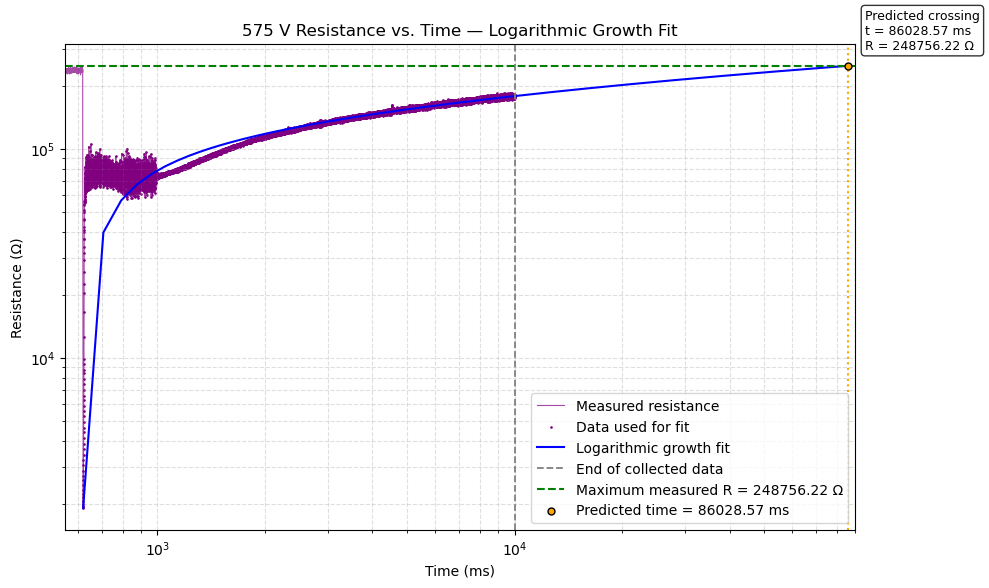

In [368]:
# ============================================================
# 575 V Resistance vs. Time
# Logarithmic Growth Fit from Minimum Resistance
# Extended Until Maximum Measured Resistance
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

lamp = 575

# ============================================================
# Load data
# ============================================================

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
    & (time > 0)
)

time = time[mask]
resistance = resistance[mask]

# Sort chronologically
sort_idx = np.argsort(time)

time = time[sort_idx]
resistance = resistance[sort_idx]

# ============================================================
# Find minimum and maximum resistance
# ============================================================

min_index = np.argmin(resistance)

t_min = time[min_index]
R_min = resistance[min_index]

# Maximum resistance in the ENTIRE dataset
R_max = np.max(resistance)

print("=" * 60)
print(f"LAMP: {lamp} V")
print("=" * 60)

print(f"Minimum resistance = {R_min:.3f} Ω")
print(f"Time of minimum = {t_min:.6f} s")

print(f"Maximum measured resistance = {R_max:.3f} Ω")

# ============================================================
# Use only data from minimum resistance onward
# ============================================================

time_fit = time[min_index:]
R_fit_data = resistance[min_index:]

print("\nFit range:")
print(f"Start: {time_fit[0]:.6f} s")
print(f"End:   {time_fit[-1]:.6f} s")
print(f"Number of points: {len(time_fit)}")

# ============================================================
# Convert time to elapsed time after minimum
#
# dt = 0 at minimum resistance
# ============================================================

dt = time_fit - t_min

# ============================================================
# Logarithmic growth model
#
# R(t) = R_min + a * ln(1 + dt/tau)
#
# This guarantees:
#
# R(t_min) = R_min
#
# because ln(1) = 0.
# ============================================================

def log_growth_model(dt, a, tau):

    return (
        R_min
        + a * np.log(
            1 + dt / tau
        )
    )

# ============================================================
# Initial guesses
# ============================================================

R_difference = R_fit_data[-1] - R_min

if R_difference > 0:

    a_guess = R_difference

else:

    a_guess = 1.0

time_range = dt[-1]

if time_range > 0:

    tau_guess = time_range / 10

else:

    tau_guess = 1.0

initial_guess = [
    a_guess,
    tau_guess
]

# ============================================================
# Fit logarithmic model
# ============================================================

popt, pcov = curve_fit(
    log_growth_model,
    dt,
    R_fit_data,
    p0=initial_guess,
    bounds=(
        [0, 1e-12],
        [np.inf, np.inf]
    ),
    maxfev=200000
)

a, tau = popt

# ============================================================
# Calculate fitted values
# ============================================================

R_pred = log_growth_model(
    dt,
    a,
    tau
)

# ============================================================
# R²
# ============================================================

ss_res = np.sum(
    (R_fit_data - R_pred) ** 2
)

ss_tot = np.sum(
    (R_fit_data - np.mean(R_fit_data)) ** 2
)

R_squared = 1 - ss_res / ss_tot

# ============================================================
# Find predicted time where fit reaches R_max
#
# R_max = R_min + a*ln(1 + dt/tau)
#
# Solve:
#
# dt = tau * [exp((R_max-R_min)/a) - 1]
# ============================================================

if R_max > R_min and a > 0:

    dt_Rmax = (
        tau
        * (
            np.exp(
                (R_max - R_min) / a
            )
            - 1
        )
    )

    t_Rmax = t_min + dt_Rmax

else:

    dt_Rmax = np.nan
    t_Rmax = np.nan

# ============================================================
# Print fit results
# ============================================================

print("\n" + "=" * 60)
print("LOGARITHMIC GROWTH FIT")
print("=" * 60)

print(f"a   = {a:.6g} Ω")
print(f"tau = {tau:.6g} s")
print(f"R²  = {R_squared:.6f}")

print("\nModel:")
print(
    "R(t) = R_min + "
    "a * ln(1 + (t-t_min)/tau)"
)

if np.isfinite(t_Rmax):

    print("\nPredicted maximum-resistance crossing:")
    print(f"Target R = {R_max:.3f} Ω")
    print(f"Predicted time = {t_Rmax:.6f} s")
    print(f"Predicted time = {t_Rmax * 1000:.3f} ms")

# ============================================================
# Generate extended curve
# ============================================================

if np.isfinite(t_Rmax):

    # Extend slightly past Rmax
    t_end = t_Rmax * 1.01

else:

    t_end = time_fit[-1] * 1.5

# Use linear spacing in time
t_curve = np.linspace(
    t_min,
    t_end,
    1000
)

dt_curve = t_curve - t_min

R_curve = log_growth_model(
    dt_curve,
    a,
    tau
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 6))

# ------------------------------------------------------------
# All measured data
# ------------------------------------------------------------

plt.plot(
    time * 1000,
    resistance,
    linewidth=0.8,
    color="purple",
    alpha = 0.7,
    label="Measured resistance"
)

# ------------------------------------------------------------
# Data used for logarithmic fit
# ------------------------------------------------------------

plt.scatter(
    time_fit * 1000,
    R_fit_data,
    s=0.8,
    color="purple",
    #zorder=4,
    label="Data used for fit"
)

# ------------------------------------------------------------
# Minimum resistance
# ------------------------------------------------------------

# plt.scatter(
#     t_min * 1000,
#     R_min,
#     s=25,
#     color="red",
#     zorder=6,
#     label=f"Minimum R = {R_min:.2f} Ω"
# )

# ------------------------------------------------------------
# Extended logarithmic fit
# ------------------------------------------------------------

plt.plot(
    t_curve * 1000,
    R_curve,
    linewidth=1.5,
    color="blue",
    label="Logarithmic growth fit"
)

# ------------------------------------------------------------
# End of collected data
# ------------------------------------------------------------

plt.axvline(
    time_fit[-1] * 1000,
    color="gray",
    linestyle="--",
    linewidth=1.3,
    label="End of collected data"
)

# ------------------------------------------------------------
# Maximum measured resistance
# ------------------------------------------------------------

plt.axhline(
    R_max,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"Maximum measured R = {R_max:.2f} Ω"
)

# ------------------------------------------------------------
# Predicted crossing
# ------------------------------------------------------------

if np.isfinite(t_Rmax):

    plt.scatter(
        t_Rmax * 1000,
        R_max,
        s=25,
        color="orange",
        edgecolor="black",
        linewidth=1,
        zorder=7,
        label=f"Predicted time = {t_Rmax * 1000:.2f} ms"
    )

    plt.axvline(
        t_Rmax * 1000,
        color="orange",
        linestyle=":",
        linewidth=1.5
    )

    plt.annotate(
        (
            f"Predicted crossing\n"
            f"t = {t_Rmax * 1000:.2f} ms\n"
            f"R = {R_max:.2f} Ω"
        ),
        xy=(
            t_Rmax * 1000,
            R_max
        ),
        xytext=(12, 12),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

# ============================================================
# Axes
# ============================================================

plt.xscale("log")
plt.yscale("log")


plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")

plt.title(
    "575 V Resistance vs. Time — "
    "Logarithmic Growth Fit"
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.xlim(550, 90000)  # Start x-axis at 0.5 ms
plt.legend()

plt.tight_layout()
plt.show()

LAMP: 575 V
Minimum resistance = 1913.802342 Ω
Minimum time = 0.619700 s (619.700 ms)

Number of points used = 76
Fit starts at = 619.700000 ms
Fit ends at = 627.200000 ms

Maximum resistance in fit data = 81699.346405 Ω

LOGISTIC GROWTH FIT
K = 81699.428105 Ω
A = 41.689585
r = 798.825 1/s
r = 798825 1/ms
R² = 0.961169

Model:
R(t) = K / (1 + A * exp(-r * (t - t_min)))

Substituting fitted parameters:
R(t) = 81699.428105 / (1 + 41.689585 * exp(-798.825 * (t - t_min)))

PREDICTED MAXIMUM-RESISTANCE CROSSING
Target R = 81699.346405 Ω
Predicted time = 0.641664 s
Predicted time = 641.664457 ms


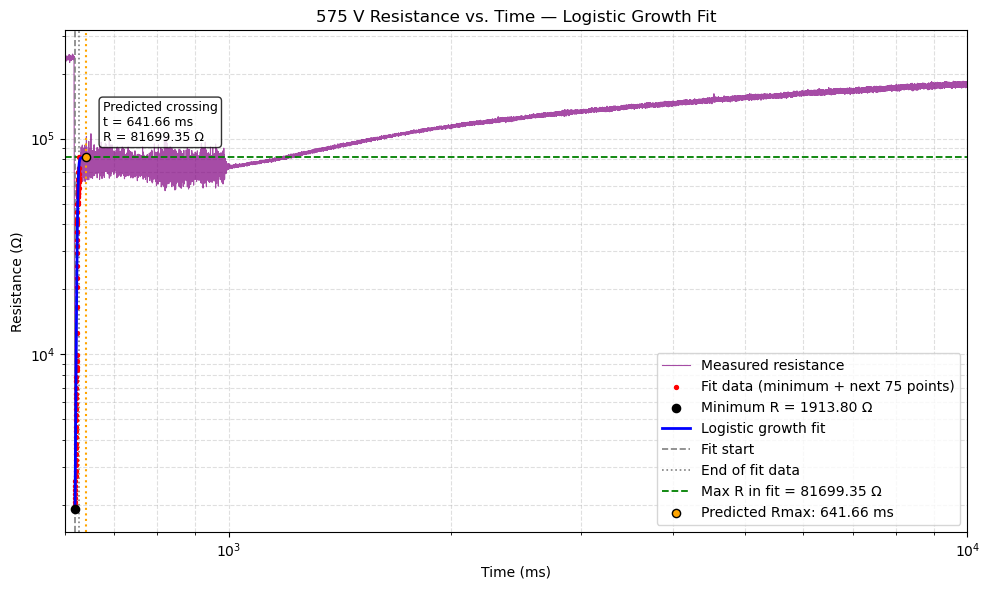

In [369]:
# ============================================================
# 575 V Resistance vs. Time
# Logistic Growth Fit
# Starting from Minimum Resistance
# Using Minimum + Next 100 Data Points
#
# Model:
#
#        K
# R(t) = ----------------
#        1 + A exp(-r t)
#
# with:
#
# A = K/R_min - 1
#
# so that:
#
# R(0) = R_min
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


lamp = 575

# ============================================================
# Number of points after minimum
# ============================================================

NUM_POINTS_AFTER_MIN = 75


# ============================================================
# Load data
# ============================================================

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()


# ============================================================
# Remove invalid values
# ============================================================

mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
    & (time > 0)
)

time = time[mask]
resistance = resistance[mask]


# ============================================================
# Sort chronologically
# ============================================================

sort_idx = np.argsort(time)

time = time[sort_idx]
resistance = resistance[sort_idx]


# ============================================================
# Find minimum resistance in ORIGINAL dataset
# ============================================================

min_index = np.argmin(resistance)

t_min = time[min_index]
R_min = resistance[min_index]


# ============================================================
# Select minimum + next 100 points
# ============================================================

fit_start_index = min_index

fit_end_index = min(
    min_index + NUM_POINTS_AFTER_MIN + 1,
    len(time)
)

time_fit = time[
    fit_start_index:fit_end_index
]

R_fit_data = resistance[
    fit_start_index:fit_end_index
]


# ============================================================
# Check number of points
# ============================================================

if len(time_fit) < 3:

    raise ValueError(
        "Not enough data points after the minimum "
        "to perform a logistic fit."
    )


# ============================================================
# Convert time to elapsed time after minimum
#
# dt = 0 at minimum resistance
# ============================================================

dt = time_fit - t_min


# ============================================================
# Maximum resistance in fitting region
# ============================================================

R_max_fit = np.max(
    R_fit_data
)


# ============================================================
# Logistic model
#
# R(dt) = K / (1 + A exp(-r dt))
#
# We enforce:
#
# R(0) = R_min
#
# Therefore:
#
# R_min = K / (1 + A)
#
# A = K/R_min - 1
#
# This leaves K and r as the parameters to fit.
# ============================================================

def logistic_model(
    dt,
    K,
    r
):

    A = (
        K / R_min
        - 1
    )

    return (
        K
        / (
            1
            + A
            * np.exp(
                -r * dt
            )
        )
    )


# ============================================================
# Initial guesses
# ============================================================

# K should be above the largest measured resistance
# in the fitting region.

K_guess = (
    R_max_fit * 1.10
)


# Estimate r based on the time range
time_range = dt[-1]

if time_range > 0:

    r_guess = (
        np.log(10)
        / time_range
    )

else:

    r_guess = 1.0


initial_guess = [
    K_guess,
    r_guess
]


# ============================================================
# Fit logistic model
# ============================================================

popt, pcov = curve_fit(
    logistic_model,
    dt,
    R_fit_data,
    p0=initial_guess,
    bounds=(
        [
            R_max_fit * 1.000001,
            0
        ],
        [
            np.inf,
            np.inf
        ]
    ),
    maxfev=500000
)


K, r = popt


# ============================================================
# Calculate A
# ============================================================

A = (
    K / R_min
    - 1
)


# ============================================================
# Calculate fitted values
# ============================================================

R_pred = logistic_model(
    dt,
    K,
    r
)


# ============================================================
# Calculate R²
# ============================================================

ss_res = np.sum(
    (
        R_fit_data
        - R_pred
    ) ** 2
)

ss_tot = np.sum(
    (
        R_fit_data
        - np.mean(R_fit_data)
    ) ** 2
)

if ss_tot > 0:

    R_squared = (
        1
        - ss_res / ss_tot
    )

else:

    R_squared = np.nan


# ============================================================
# Find time where logistic fit reaches
# maximum resistance in fitting region
#
# R_max = K / (1 + A exp(-r dt))
#
# Solve:
#
# dt = -1/r * ln[
#       (K/R_max - 1) / A
#      ]
# ============================================================

if (
    R_max_fit < K
    and A > 0
    and r > 0
):

    dt_Rmax = (
        -1
        / r
        * np.log(
            (
                K / R_max_fit
                - 1
            )
            / A
        )
    )

    t_Rmax = (
        t_min
        + dt_Rmax
    )

else:

    dt_Rmax = np.nan
    t_Rmax = np.nan


# ============================================================
# Print results
# ============================================================

print("=" * 60)
print(f"LAMP: {lamp} V")
print("=" * 60)

print(
    f"Minimum resistance = "
    f"{R_min:.6f} Ω"
)

print(
    f"Minimum time = "
    f"{t_min:.6f} s "
    f"({t_min * 1000:.3f} ms)"
)

print(
    f"\nNumber of points used = "
    f"{len(time_fit)}"
)

print(
    f"Fit starts at = "
    f"{time_fit[0] * 1000:.6f} ms"
)

print(
    f"Fit ends at = "
    f"{time_fit[-1] * 1000:.6f} ms"
)

print(
    f"\nMaximum resistance in fit data = "
    f"{R_max_fit:.6f} Ω"
)


# ============================================================
# Print logistic fit parameters
# ============================================================

print("\n" + "=" * 60)
print("LOGISTIC GROWTH FIT")
print("=" * 60)

print(
    f"K = {K:.6f} Ω"
)

print(
    f"A = {A:.6f}"
)

print(
    f"r = {r:.6g} 1/s"
)

print(
    f"r = {r * 1000:.6g} 1/ms"
)

print(
    f"R² = {R_squared:.6f}"
)


# ============================================================
# Print model
# ============================================================

print("\nModel:")

print(
    "R(t) = K / "
    "(1 + A * exp(-r * (t - t_min)))"
)

print(
    "\nSubstituting fitted parameters:"
)

print(
    f"R(t) = {K:.6f} / "
    f"(1 + {A:.6f} * "
    f"exp(-{r:.6g} * (t - t_min)))"
)


# ============================================================
# Predicted Rmax crossing
# ============================================================

if np.isfinite(t_Rmax):

    print(
        "\n" + "=" * 60
    )

    print(
        "PREDICTED MAXIMUM-RESISTANCE CROSSING"
    )

    print(
        "=" * 60
    )

    print(
        f"Target R = "
        f"{R_max_fit:.6f} Ω"
    )

    print(
        f"Predicted time = "
        f"{t_Rmax:.6f} s"
    )

    print(
        f"Predicted time = "
        f"{t_Rmax * 1000:.6f} ms"
    )


# ============================================================
# Generate extended logistic curve
# ============================================================

if np.isfinite(t_Rmax):

    # Extend slightly beyond Rmax
    t_end = (
        t_Rmax * 1.01
    )

else:

    # If Rmax crossing cannot be calculated,
    # extend 50% beyond the fit range.
    t_end = (
        time_fit[-1]
        + 0.5 * (
            time_fit[-1]
            - t_min
        )
    )


# Make sure curve begins at minimum
t_curve = np.linspace(
    t_min,
    t_end,
    1000
)


# Convert to elapsed time
dt_curve = (
    t_curve
    - t_min
)


# Calculate logistic curve
R_curve = logistic_model(
    dt_curve,
    K,
    r
)


# ============================================================
# Plot
# ============================================================

plt.figure(
    figsize=(10, 6)
)


# ------------------------------------------------------------
# Original measured data
# ------------------------------------------------------------

plt.plot(
    time * 1000,
    resistance,
    linewidth=0.8,
    color="purple",
    alpha=0.7,
    label="Measured resistance"
)


# ------------------------------------------------------------
# Data used for logistic fit
# ------------------------------------------------------------

plt.scatter(
    time_fit * 1000,
    R_fit_data,
    s=8,
    color="red",
    zorder=5,
    label=(
        f"Fit data "
        f"(minimum + next "
        f"{NUM_POINTS_AFTER_MIN} points)"
    )
)


# ------------------------------------------------------------
# Minimum resistance
# ------------------------------------------------------------

plt.scatter(
    t_min * 1000,
    R_min,
    s=35,
    color="black",
    zorder=7,
    label=(
        f"Minimum R = "
        f"{R_min:.2f} Ω"
    )
)


# ------------------------------------------------------------
# Logistic fit
# ------------------------------------------------------------

plt.plot(
    t_curve * 1000,
    R_curve,
    linewidth=2,
    color="blue",
    zorder=6,
    label="Logistic growth fit"
)


# ------------------------------------------------------------
# Fit start
# ------------------------------------------------------------

plt.axvline(
    t_min * 1000,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Fit start"
)


# ------------------------------------------------------------
# End of collected fit data
# ------------------------------------------------------------

plt.axvline(
    time_fit[-1] * 1000,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label="End of fit data"
)


# ------------------------------------------------------------
# Maximum resistance in fit data
# ------------------------------------------------------------

plt.axhline(
    R_max_fit,
    color="green",
    linestyle="--",
    linewidth=1.3,
    label=(
        f"Max R in fit = "
        f"{R_max_fit:.2f} Ω"
    )
)


# ------------------------------------------------------------
# Predicted Rmax crossing
# ------------------------------------------------------------

if np.isfinite(t_Rmax):

    plt.scatter(
        t_Rmax * 1000,
        R_max_fit,
        s=35,
        color="orange",
        edgecolor="black",
        linewidth=1,
        zorder=8,
        label=(
            f"Predicted Rmax: "
            f"{t_Rmax * 1000:.2f} ms"
        )
    )

    plt.axvline(
        t_Rmax * 1000,
        color="orange",
        linestyle=":",
        linewidth=1.5
    )

    plt.annotate(
        (
            f"Predicted crossing\n"
            f"t = {t_Rmax * 1000:.2f} ms\n"
            f"R = {R_max_fit:.2f} Ω"
        ),
        xy=(
            t_Rmax * 1000,
            R_max_fit
        ),
        xytext=(12, 12),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )


# ============================================================
# Axes
# ============================================================

plt.xscale("log")
plt.yscale("log")

plt.xlabel(
    "Time (ms)"
)

plt.ylabel(
    "Resistance (Ω)"
)

plt.title(
    "575 V Resistance vs. Time — "
    "Logistic Growth Fit"
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.xlim(
    600,
    10000
)


plt.legend()

plt.tight_layout()

plt.show()

Lamp: 575 V
Minimum resistance: 1913.80 Ω
Time of minimum resistance: 0.619700 s
Number of points used for fit: 93803

Post-minimum exponential recovery fit:
R(t) = 166520 - (166520 - 1913.8) * exp(-0.815351 * (t - 0.6197))
R_inf = 166519.740249 Ω
k = 0.815351 s⁻¹
R² = 0.796124


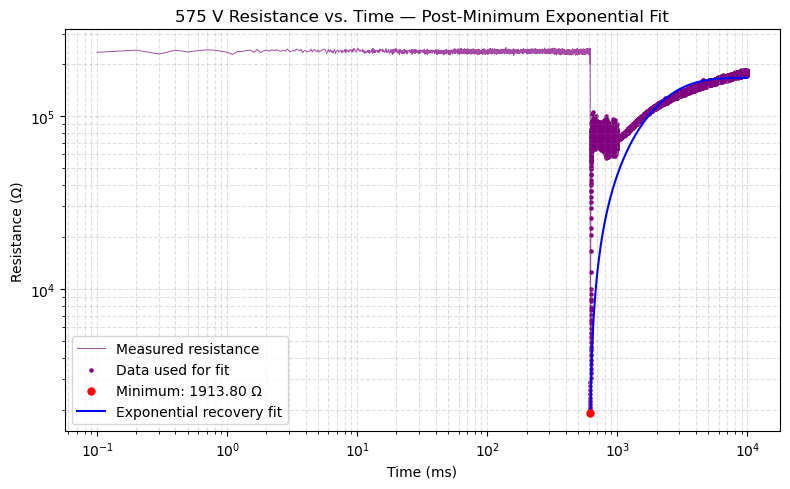

In [370]:
#575 GOOD VERSION
# Fit starting at the lowest resistance point and onwards
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

lamp = 575

# ============================================================
# Load data
# ============================================================

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
    & (time > 0)
)

time = time[mask]
resistance = resistance[mask]

# Sort by time
sort_idx = np.argsort(time)

time = time[sort_idx]
resistance = resistance[sort_idx]

# ============================================================
# Find lowest resistance point
# ============================================================

min_index = np.argmin(resistance)

t_min = time[min_index]
R_min = resistance[min_index]

print(f"Lamp: {lamp} V")
print(f"Minimum resistance: {R_min:.2f} Ω")
print(f"Time of minimum resistance: {t_min:.6f} s")

# ============================================================
# Keep ONLY data from minimum resistance onwards
# ============================================================

time_fit_data = time[min_index:]
resistance_fit_data = resistance[min_index:]

print(f"Number of points used for fit: {len(time_fit_data)}")

# ============================================================
# Exponential recovery model
#
# R(t) = R_inf - (R_inf - R_min) * exp(-k*(t-t_min))
#
# ============================================================

def recovery_model(t, R_inf, k):
    return (
        R_inf
        - (R_inf - R_min)
        * np.exp(-k * (t - t_min))
    )

# ============================================================
# Initial guesses
# ============================================================

R_inf_guess = resistance_fit_data[-1]
k_guess = 0.5

initial_guess = [
    R_inf_guess,
    k_guess
]

# ============================================================
# Fit
# ============================================================

popt, pcov = curve_fit(
    recovery_model,
    time_fit_data,
    resistance_fit_data,
    p0=initial_guess,
    bounds=(
        [R_min, 0],
        [np.inf, np.inf]
    ),
    maxfev=100000
)

R_inf, k = popt

# ============================================================
# Generate smooth fitted curve
# ============================================================

t_smooth = np.logspace(
    np.log10(time_fit_data.min()),
    np.log10(time_fit_data.max()),
    500
)

R_smooth = recovery_model(t_smooth, R_inf, k)

# ============================================================
# Calculate R²
# ============================================================

R_pred = recovery_model(
    time_fit_data,
    R_inf,
    k
)

ss_res = np.sum(
    (resistance_fit_data - R_pred) ** 2
)

ss_tot = np.sum(
    (resistance_fit_data - np.mean(resistance_fit_data)) ** 2
)

r_squared = 1 - ss_res / ss_tot

# ============================================================
# Print fit
# ============================================================

print("\nPost-minimum exponential recovery fit:")
print(
    f"R(t) = {R_inf:.6g} "
    f"- ({R_inf:.6g} - {R_min:.6g}) "
    f"* exp(-{k:.6g} * (t - {t_min:.6g}))"
)

print(f"R_inf = {R_inf:.6f} Ω")
print(f"k = {k:.6g} s⁻¹")
print(f"R² = {r_squared:.6f}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

# All measured data
plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.7,
    color="purple",
    alpha = 0.7,
    label="Measured resistance"
)

# Data actually used for fit
plt.scatter(
    time_fit_data * 1e3,
    resistance_fit_data,
    s=5,
    color="purple",
    label="Data used for fit"
)

# Minimum resistance
plt.scatter(
    t_min * 1e3,
    R_min,
    s=25,
    color="red",
    zorder=5,
    label=f"Minimum: {R_min:.2f} Ω"
)

# Fitted curve
plt.plot(
    t_smooth * 1e3,
    R_smooth,
    linewidth=1.5,
    color="blue",
    label="Exponential recovery fit"
)

# ============================================================
# Axes
# ============================================================

plt.xscale("log")
plt.yscale("log")


plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title(
    "575 V Resistance vs. Time — "
    "Post-Minimum Exponential Fit"
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()
plt.show()

Lamp: 600 V
Minimum resistance: 498.13 Ω
Time of minimum resistance: 0.649200 s
Number of points used for fit: 93508

Post-minimum exponential recovery fit:
R(t) = 171769 - (171769 - 498.129) * exp(-0.762 * (t - 0.6492))
R_inf = 171768.504553 Ω
k = 0.762 s⁻¹
R² = 0.851108


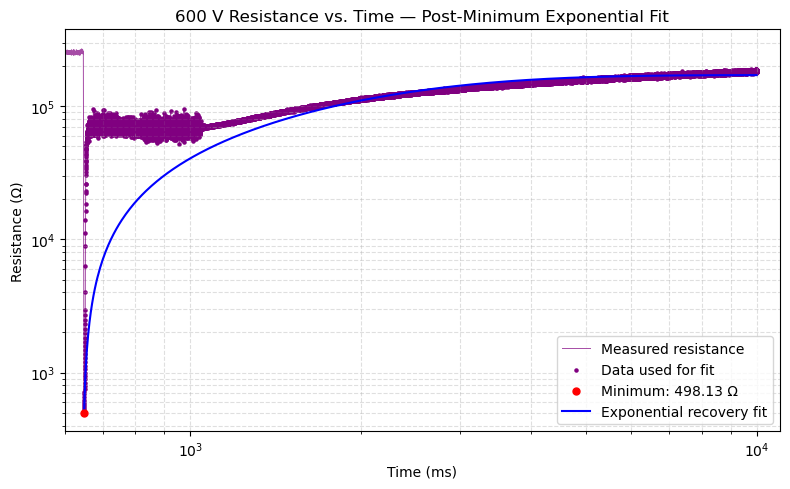

In [371]:
#600 GOOD VERSION
# Fit starting at the lowest resistance point and onwards
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

lamp = 600

# ============================================================
# Load data
# ============================================================

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
    & (time > 0)
)

time = time[mask]
resistance = resistance[mask]

# Sort by time
sort_idx = np.argsort(time)

time = time[sort_idx]
resistance = resistance[sort_idx]

# ============================================================
# Find lowest resistance point
# ============================================================

min_index = np.argmin(resistance)

t_min = time[min_index]
R_min = resistance[min_index]

print(f"Lamp: {lamp} V")
print(f"Minimum resistance: {R_min:.2f} Ω")
print(f"Time of minimum resistance: {t_min:.6f} s")

# ============================================================
# Keep ONLY data from minimum resistance onwards
# ============================================================

time_fit_data = time[min_index:]
resistance_fit_data = resistance[min_index:]

print(f"Number of points used for fit: {len(time_fit_data)}")

# ============================================================
# Exponential recovery model
#
# R(t) = R_inf - (R_inf - R_min) * exp(-k*(t-t_min))
#
# ============================================================

def recovery_model(t, R_inf, k):
    return (
        R_inf
        - (R_inf - R_min)
        * np.exp(-k * (t - t_min))
    )

# ============================================================
# Initial guesses
# ============================================================

R_inf_guess = resistance_fit_data[-1]
k_guess = 0.5

initial_guess = [
    R_inf_guess,
    k_guess
]

# ============================================================
# Fit
# ============================================================

popt, pcov = curve_fit(
    recovery_model,
    time_fit_data,
    resistance_fit_data,
    p0=initial_guess,
    bounds=(
        [R_min, 0],
        [np.inf, np.inf]
    ),
    maxfev=100000
)

R_inf, k = popt

# ============================================================
# Generate smooth fitted curve
# ============================================================

t_smooth = np.logspace(
    np.log10(time_fit_data.min()),
    np.log10(time_fit_data.max()),
    500
)

R_smooth = recovery_model(t_smooth, R_inf, k)

# ============================================================
# Calculate R²
# ============================================================

R_pred = recovery_model(
    time_fit_data,
    R_inf,
    k
)

ss_res = np.sum(
    (resistance_fit_data - R_pred) ** 2
)

ss_tot = np.sum(
    (resistance_fit_data - np.mean(resistance_fit_data)) ** 2
)

r_squared = 1 - ss_res / ss_tot

# ============================================================
# Print fit
# ============================================================

print("\nPost-minimum exponential recovery fit:")
print(
    f"R(t) = {R_inf:.6g} "
    f"- ({R_inf:.6g} - {R_min:.6g}) "
    f"* exp(-{k:.6g} * (t - {t_min:.6g}))"
)

print(f"R_inf = {R_inf:.6f} Ω")
print(f"k = {k:.6g} s⁻¹")
print(f"R² = {r_squared:.6f}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

# All measured data
plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.7,
    color="purple",
    alpha = 0.7,
    label="Measured resistance"
)

# Data actually used for fit
plt.scatter(
    time_fit_data * 1e3,
    resistance_fit_data,
    s=5,
    color="purple",
    label="Data used for fit"
)

# Minimum resistance
plt.scatter(
    t_min * 1e3,
    R_min,
    s=25,
    color="red",
    zorder=5,
    label=f"Minimum: {R_min:.2f} Ω"
)

# Fitted curve
plt.plot(
    t_smooth * 1e3,
    R_smooth,
    linewidth=1.5,
    color="blue",
    label="Exponential recovery fit"
)

# ============================================================
# Axes
# ============================================================

plt.xscale("log")
plt.yscale("log")

plt.xlim(600, 11000)

plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title(
    "600 V Resistance vs. Time — "
    "Post-Minimum Exponential Fit"
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()
plt.show()

Lamp: 600 V
Minimum resistance: 498.13 Ω
Time of minimum resistance: 0.649200 s
Number of points used for fit: 93508

Post-minimum exponential recovery fit:
R(t) = 171769 - (171769 - 498.129) * exp(-0.762 * (t - 0.6492))
R_inf = 171768.504553 Ω
k = 0.762 s⁻¹
R² = 0.851108


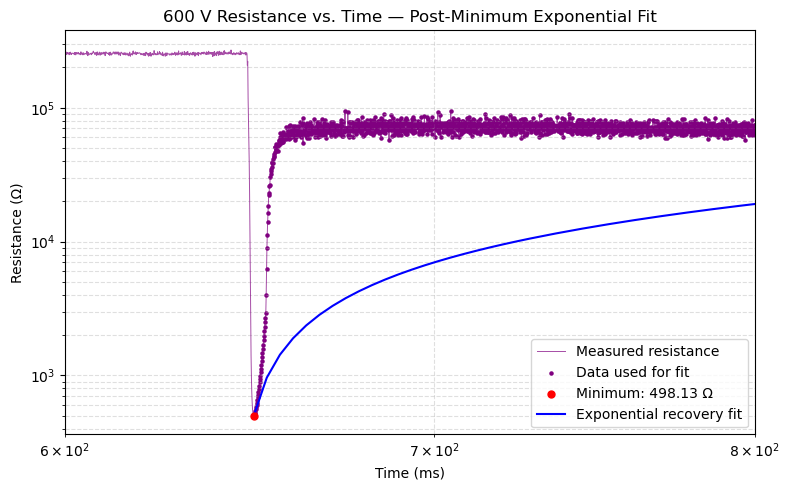

In [372]:
#600 GOOD VERSION
# Fit starting at the lowest resistance point and onwards
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

lamp = 600

# ============================================================
# Load data
# ============================================================

lamp_data = data[lamp]

time = lamp_data["Time (s)"].to_numpy()
resistance = lamp_data["Resistance (Ω)"].to_numpy()

# Remove invalid values
mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
    & (time > 0)
)

time = time[mask]
resistance = resistance[mask]

# Sort by time
sort_idx = np.argsort(time)

time = time[sort_idx]
resistance = resistance[sort_idx]

# ============================================================
# Find lowest resistance point
# ============================================================

min_index = np.argmin(resistance)

t_min = time[min_index]
R_min = resistance[min_index]

print(f"Lamp: {lamp} V")
print(f"Minimum resistance: {R_min:.2f} Ω")
print(f"Time of minimum resistance: {t_min:.6f} s")

# ============================================================
# Keep ONLY data from minimum resistance onwards
# ============================================================

time_fit_data = time[min_index:]
resistance_fit_data = resistance[min_index:]

print(f"Number of points used for fit: {len(time_fit_data)}")

# ============================================================
# Exponential recovery model
#
# R(t) = R_inf - (R_inf - R_min) * exp(-k*(t-t_min))
#
# ============================================================

def recovery_model(t, R_inf, k):
    return (
        R_inf
        - (R_inf - R_min)
        * np.exp(-k * (t - t_min))
    )

# ============================================================
# Initial guesses
# ============================================================

R_inf_guess = resistance_fit_data[-1]
k_guess = 0.5

initial_guess = [
    R_inf_guess,
    k_guess
]

# ============================================================
# Fit
# ============================================================

popt, pcov = curve_fit(
    recovery_model,
    time_fit_data,
    resistance_fit_data,
    p0=initial_guess,
    bounds=(
        [R_min, 0],
        [np.inf, np.inf]
    ),
    maxfev=100000
)

R_inf, k = popt

# ============================================================
# Generate smooth fitted curve
# ============================================================

t_smooth = np.logspace(
    np.log10(time_fit_data.min()),
    np.log10(time_fit_data.max()),
    500
)

R_smooth = recovery_model(t_smooth, R_inf, k)

# ============================================================
# Calculate R²
# ============================================================

R_pred = recovery_model(
    time_fit_data,
    R_inf,
    k
)

ss_res = np.sum(
    (resistance_fit_data - R_pred) ** 2
)

ss_tot = np.sum(
    (resistance_fit_data - np.mean(resistance_fit_data)) ** 2
)

r_squared = 1 - ss_res / ss_tot

# ============================================================
# Print fit
# ============================================================

print("\nPost-minimum exponential recovery fit:")
print(
    f"R(t) = {R_inf:.6g} "
    f"- ({R_inf:.6g} - {R_min:.6g}) "
    f"* exp(-{k:.6g} * (t - {t_min:.6g}))"
)

print(f"R_inf = {R_inf:.6f} Ω")
print(f"k = {k:.6g} s⁻¹")
print(f"R² = {r_squared:.6f}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

# All measured data
plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.7,
    color="purple",
    alpha = 0.7,
    label="Measured resistance"
)

# Data actually used for fit
plt.scatter(
    time_fit_data * 1e3,
    resistance_fit_data,
    s=5,
    color="purple",
    label="Data used for fit"
)

# Minimum resistance
plt.scatter(
    t_min * 1e3,
    R_min,
    s=25,
    color="red",
    zorder=5,
    label=f"Minimum: {R_min:.2f} Ω"
)

# Fitted curve
plt.plot(
    t_smooth * 1e3,
    R_smooth,
    linewidth=1.5,
    color="blue",
    label="Exponential recovery fit"
)

# ============================================================
# Axes
# ============================================================

plt.xscale("log")
plt.yscale("log")

plt.xlim(600, 800)

plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.title(
    "600 V Resistance vs. Time — "
    "Post-Minimum Exponential Fit"
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()
plt.show()

## char and fit

Predicted voltages from resistance model:
Midpoint Resistance          Rm = 6458.24 Ω
  Required Voltage = 568.92 V

Midpoint Warming Resistance = 22881.10 Ω
  Required Voltage = 542.83 V

Midpoint Cooling Resistance = 1822.85 Ω
  Required Voltage = 585.38 V


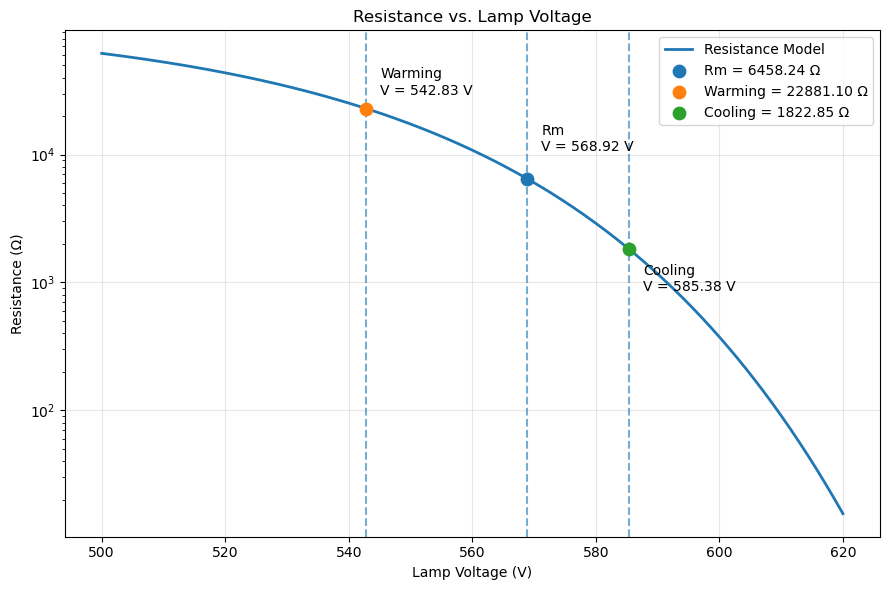

In [373]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Resistance Model
# ============================================================

def resistance_model(V):
    """
    Predict resistance (Ohms) from lamp voltage (V).

    R(V) = exp(-1.02945e-05 * exp(0.0220516 * V) + 11.6645)
    """
    return np.exp(
        -1.02945e-5 * np.exp(0.0220516 * V)
        + 11.6645
    )


# ============================================================
# Inverse Model: Find Voltage for a Target Resistance
# ============================================================

def voltage_for_resistance(R):
    """
    Calculate the voltage required to reach a target resistance R.

    Inverting:
        R = exp(-a * exp(bV) + c)

    gives:
        V = ln((c - ln(R))/a) / b
    """

    a = 1.02945e-5
    b = 0.0220516
    c = 11.6645

    return np.log((c - np.log(R)) / a) / b


# ============================================================
# Target Resistances
# ============================================================

Rm = 6458.24
Rm_warming = 22881.1
Rm_cooling = 1822.85

V_Rm = voltage_for_resistance(Rm)
V_warming = voltage_for_resistance(Rm_warming)
V_cooling = voltage_for_resistance(Rm_cooling)


# ============================================================
# Print Results
# ============================================================

print("Predicted voltages from resistance model:")
print(f"Midpoint Resistance          Rm = {Rm:.2f} Ω")
print(f"  Required Voltage = {V_Rm:.2f} V")
print()

print(f"Midpoint Warming Resistance = {Rm_warming:.2f} Ω")
print(f"  Required Voltage = {V_warming:.2f} V")
print()

print(f"Midpoint Cooling Resistance = {Rm_cooling:.2f} Ω")
print(f"  Required Voltage = {V_cooling:.2f} V")


# ============================================================
# Plot Resistance Model
# ============================================================

# Voltage range covering all three predicted voltages
V_min = 500
V_max = 620

V_values = np.linspace(V_min, V_max, 1000)
R_values = resistance_model(V_values)

plt.figure(figsize=(9, 6))

# Model curve
plt.plot(
    V_values,
    R_values,
    linewidth=2,
    label="Resistance Model"
)

# Target points
plt.scatter(
    V_Rm,
    Rm,
    s=80,
    zorder=5,
    label=f"Rm = {Rm:.2f} Ω"
)

plt.scatter(
    V_warming,
    Rm_warming,
    s=80,
    zorder=5,
    label=f"Warming = {Rm_warming:.2f} Ω"
)

plt.scatter(
    V_cooling,
    Rm_cooling,
    s=80,
    zorder=5,
    label=f"Cooling = {Rm_cooling:.2f} Ω"
)

# Vertical lines showing predicted voltages
plt.axvline(
    V_Rm,
    linestyle="--",
    alpha=0.6
)

plt.axvline(
    V_warming,
    linestyle="--",
    alpha=0.6
)

plt.axvline(
    V_cooling,
    linestyle="--",
    alpha=0.6
)

# Labels
plt.annotate(
    f"Rm\nV = {V_Rm:.2f} V",
    xy=(V_Rm, Rm),
    xytext=(10, 20),
    textcoords="offset points"
)

plt.annotate(
    f"Warming\nV = {V_warming:.2f} V",
    xy=(V_warming, Rm_warming),
    xytext=(10, 10),
    textcoords="offset points"
)

plt.annotate(
    f"Cooling\nV = {V_cooling:.2f} V",
    xy=(V_cooling, Rm_cooling),
    xytext=(10, -30),
    textcoords="offset points"
)

plt.xlabel("Lamp Voltage (V)")
plt.ylabel("Resistance (Ω)")
plt.yscale("log")
plt.title("Resistance vs. Lamp Voltage")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## hysteresis electrical

WARNING *** file size (13143) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (11088) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (13137) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (13143) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (11098) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (13143) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (11098) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero

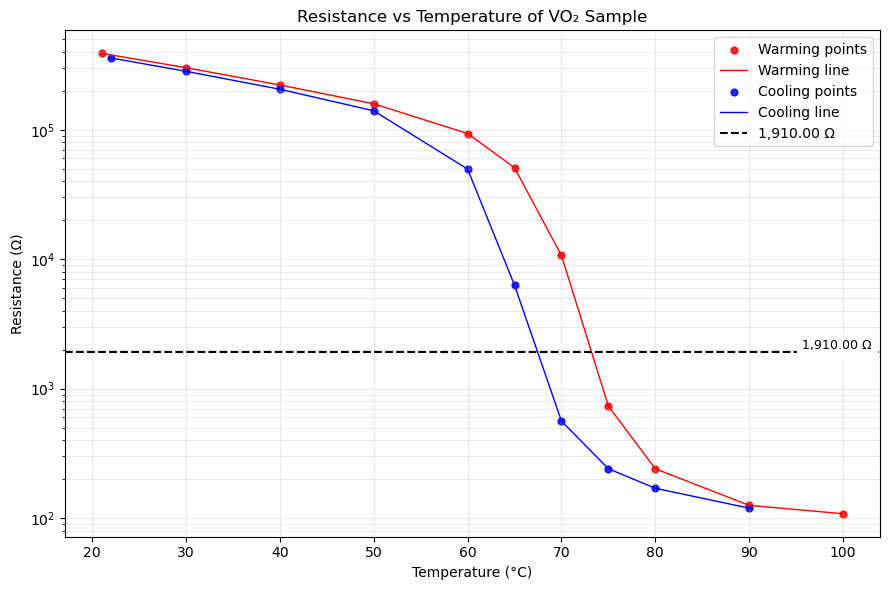


Summary Preview:
   temperature_C  Mean_Resistance  Standard_Deviation  Measurement_Count
0           21.0    389565.082259                 NaN                  1
1           22.0    358739.149595                 NaN                  1
2           30.0    292331.159166        13312.072945                  2
3           40.0    213739.365618        11512.563588                  2
4           50.0    149428.769116        13144.432187                  2

Saved:
 - resistance_vs_temperature_raw.csv
 - resistance_vs_temperature_mean.csv
 - resistance_vs_temperature_plot.png


In [379]:
#!/usr/bin/env python3

import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

VO2_RESISTANCE_THRESHOLD = 1910


# ============================================================
# TEMPERATURE EXTRACTION
# ============================================================

VO2_TEMP_RE = re.compile(
    r"(-?\d+(?:\.\d+)?)C",
    re.IGNORECASE
)


def vo2_extract_temperature(filename: str) -> float:
    m = VO2_TEMP_RE.search(filename)

    if not m:
        raise ValueError(
            f"Could not find temperature in filename: {filename}"
        )

    return float(m.group(1))


# ============================================================
# FIND RESISTANCE COLUMN
# ============================================================

def vo2_find_res_column(df: pd.DataFrame) -> str | None:

    for c in df.columns:

        if str(c).strip().upper() == "RES":
            return c

    return None


# ============================================================
# PROCESS ONE EXCEL FILE
# ============================================================

def vo2_process_excel_file(path: Path) -> pd.DataFrame:

    temp_c = vo2_extract_temperature(path.stem)

    xl = pd.ExcelFile(path)

    rows = []

    for sheet in xl.sheet_names:

        df = xl.parse(
            sheet_name=sheet
        )

        res_col = vo2_find_res_column(df)

        if res_col is None:
            continue

        res_values = pd.to_numeric(
            df[res_col],
            errors="coerce"
        ).dropna()

        for r in res_values:

            # Ignore invalid resistance values
            if r <= 0:
                continue

            rows.append({
                "temperature_C": temp_c,
                "resistance": float(r),
                "file": path.name,
                "sheet": sheet
            })

    return pd.DataFrame(rows)


# ============================================================
# PROCESS ENTIRE FOLDER
# ============================================================

def vo2_process_folder(folder_path_string: str) -> pd.DataFrame:

    vo2_folder_path = Path(folder_path_string)

    vo2_all_files = sorted(
        list(vo2_folder_path.glob("*.xlsx"))
        + list(vo2_folder_path.glob("*.xls"))
    )

    vo2_all_data = []

    for vo2_file in vo2_all_files:

        try:

            vo2_file_data = vo2_process_excel_file(
                vo2_file
            )

            if not vo2_file_data.empty:
                vo2_all_data.append(vo2_file_data)

        except Exception as e:

            print(
                f"Skipping {vo2_file.name}: {e}"
            )

    if not vo2_all_data:

        return pd.DataFrame(
            columns=[
                "temperature_C",
                "resistance",
                "file",
                "sheet"
            ]
        )

    vo2_output_data = pd.concat(
        vo2_all_data,
        ignore_index=True
    )

    vo2_output_data = vo2_output_data.sort_values(
        [
            "temperature_C",
            "file",
            "sheet"
        ]
    )

    return vo2_output_data


# ============================================================
# CLASSIFY WARMING / COOLING
# ============================================================

def vo2_classify_direction(filename: str) -> str:

    vo2_name = filename.lower()

    if "up" in vo2_name:
        return "Warming"

    if "down" in vo2_name:
        return "Cooling"

    return "Unknown"


# ============================================================
# STATIC WARMING / COOLING PLOT
# ============================================================

def vo2_create_up_down_plot(
    temperature_data: pd.DataFrame,
    output_path: str =
        "resistance_vs_temperature_plot.png"
) -> None:

    # Make an independent copy so the original dataframe
    # passed into this function is never modified.
    vo2_plot_data = temperature_data.copy()

    vo2_plot_data["direction"] = (
        vo2_plot_data["file"]
        .apply(vo2_classify_direction)
    )

    vo2_plot_data = vo2_plot_data[
        vo2_plot_data["direction"].isin(
            ["Warming", "Cooling"]
        )
    ]

    if vo2_plot_data.empty:

        print(
            "\nNo Warming/Cooling data found for plotting."
        )

        return

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    # --------------------------------------------------------
    # Plot Warming and Cooling data
    # --------------------------------------------------------

    for direction, vo2_color in [
        ("Warming", "red"),
        ("Cooling", "blue")
    ]:

        vo2_direction_points = (
            vo2_plot_data[
                vo2_plot_data["direction"]
                == direction
            ]
            .sort_values(
                "temperature_C"
            )
        )

        if vo2_direction_points.empty:
            continue

        # Individual data points
        ax.scatter(
            vo2_direction_points[
                "temperature_C"
            ],
            vo2_direction_points[
                "resistance"
            ],
            color=vo2_color,
            s=18,
            alpha=0.8,
            label=f"{direction} points"
        )

        # Mean resistance at each temperature
        vo2_direction_line = (
            vo2_direction_points
            .groupby(
                "temperature_C",
                as_index=False
            )["resistance"]
            .mean()
            .sort_values(
                "temperature_C"
            )
        )

        ax.plot(
            vo2_direction_line[
                "temperature_C"
            ],
            vo2_direction_line[
                "resistance"
            ],
            color=vo2_color,
            linewidth=1.0,
            label=f"{direction} line"
        )

    # ========================================================
    # RESISTANCE THRESHOLD
    # ========================================================

    ax.axhline(
        y=VO2_RESISTANCE_THRESHOLD,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"{VO2_RESISTANCE_THRESHOLD:,.2f} Ω"
    )

    # Label directly on graph
    ax.text(
        0.99,
        VO2_RESISTANCE_THRESHOLD,
        f"{VO2_RESISTANCE_THRESHOLD:,.2f} Ω",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=9,
        backgroundcolor="white"
    )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Temperature (°C)"
    )

    ax.set_ylabel(
        "Resistance (Ω)"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_title(
        "Resistance vs Temperature (Warming/Cooling)"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.25
    )

    ax.legend()

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=300
    )

    plt.close(fig)

    print(
        f"\nSaved static plot: {output_path}"
    )


# ============================================================
# INTERACTIVE WARMING / COOLING PLOT
# ============================================================

def vo2_create_interactive_up_down_plot(
    temperature_data: pd.DataFrame
) -> None:

    # Independent copy
    vo2_plot_data = temperature_data.copy()

    vo2_plot_data["direction"] = (
        vo2_plot_data["file"]
        .apply(vo2_classify_direction)
    )

    vo2_plot_data = vo2_plot_data[
        vo2_plot_data["direction"].isin(
            ["Warming", "Cooling"]
        )
    ].reset_index(
        drop=True
    )

    if vo2_plot_data.empty:

        print(
            "\nNo Warming/Cooling data found "
            "for interactive plotting."
        )

        return

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    vo2_scatter_artists = []

    # --------------------------------------------------------
    # Plot Warming and Cooling points
    # --------------------------------------------------------

    for direction, vo2_color in [
        ("Warming", "red"),
        ("Cooling", "blue")
    ]:

        vo2_direction_points = (
            vo2_plot_data[
                vo2_plot_data["direction"]
                == direction
            ]
            .sort_values(
                "temperature_C"
            )
        )

        if vo2_direction_points.empty:
            continue

        scatter = ax.scatter(
            vo2_direction_points[
                "temperature_C"
            ],
            vo2_direction_points[
                "resistance"
            ],
            color=vo2_color,
            s=24,
            alpha=0.85,
            label=f"{direction} points",
            picker=True
        )

        # Store point information directly on the
        # scatter object without modifying the source data.
        scatter._vo2_point_data = (
            vo2_direction_points
            .reset_index(drop=True)
        )

        vo2_scatter_artists.append(
            scatter
        )

        # Mean resistance line
        vo2_direction_line = (
            vo2_direction_points
            .groupby(
                "temperature_C",
                as_index=False
            )["resistance"]
            .mean()
            .sort_values(
                "temperature_C"
            )
        )

        ax.plot(
            vo2_direction_line[
                "temperature_C"
            ],
            vo2_direction_line[
                "resistance"
            ],
            color=vo2_color,
            linewidth=1.0,
            label=f"{direction} line"
        )

    # ========================================================
    # RESISTANCE THRESHOLD
    # ========================================================

    ax.axhline(
        y=VO2_RESISTANCE_THRESHOLD,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"{VO2_RESISTANCE_THRESHOLD:,.2f} Ω"
    )

    # Label directly on graph
    ax.text(
        0.99,
        VO2_RESISTANCE_THRESHOLD,
        f"{VO2_RESISTANCE_THRESHOLD:,.2f} Ω",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=9,
        backgroundcolor="white"
    )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Temperature (°C)"
    )

    ax.set_ylabel(
        "Resistance (Ω)"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_title(
        "Resistance vs Temperature of VO₂ Sample"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.25
    )

    ax.legend()

    # ========================================================
    # INTERACTIVE ANNOTATION
    # ========================================================

    annotation = ax.annotate(
        "",
        xy=(0, 0),
        xytext=(10, 10),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="gray",
            alpha=0.95
        )
    )

    annotation.set_visible(
        False
    )

    # --------------------------------------------------------
    # Mouse click handler
    # --------------------------------------------------------

    def vo2_on_pick(event):

        artist = event.artist

        if artist not in vo2_scatter_artists:
            return

        idx = int(
            event.ind[0]
        )

        vo2_point_data = (
            artist
            ._vo2_point_data
            .iloc[idx]
        )

        x = float(
            vo2_point_data[
                "temperature_C"
            ]
        )

        y = float(
            vo2_point_data[
                "resistance"
            ]
        )

        annotation.xy = (
            x,
            y
        )

        annotation.set_text(
            f"T: {x:.3f} °C\n"
            f"R: {y:.6g} Ω\n"
            f"Direction: {vo2_point_data['direction']}\n"
            f"File: {vo2_point_data['file']}\n"
            f"Sheet: {vo2_point_data['sheet']}"
        )

        annotation.set_visible(
            True
        )

        fig.canvas.draw_idle()

    # Connect click event
    fig.canvas.mpl_connect(
        "pick_event",
        vo2_on_pick
    )

    fig.tight_layout()

    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Change this to your folder path
    # --------------------------------------------------------

    vo2_folder = "./VO2_2026"

    # --------------------------------------------------------
    # Load data
    # --------------------------------------------------------

    # IMPORTANT:
    # This is intentionally NOT called "data".
    # Your existing notebook variable "data" is therefore
    # left completely untouched.
    vo2_temperature_data = vo2_process_folder(
        vo2_folder
    )

    print(
        "Raw Data Preview:"
    )

    print(
        vo2_temperature_data.head()
    )

    # --------------------------------------------------------
    # Save raw aligned data
    # --------------------------------------------------------

    vo2_temperature_data.to_csv(
        "resistance_vs_temperature_raw.csv",
        index=False
    )

    # --------------------------------------------------------
    # Calculate summary statistics
    # --------------------------------------------------------

    vo2_temperature_summary = (
        vo2_temperature_data
        .groupby(
            "temperature_C"
        )["resistance"]
        .agg(
            Mean_Resistance="mean",
            Standard_Deviation="std",
            Measurement_Count="count"
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Save summary
    # --------------------------------------------------------

    vo2_temperature_summary.to_csv(
        "resistance_vs_temperature_mean.csv",
        index=False
    )

    # --------------------------------------------------------
    # Create static plot
    # --------------------------------------------------------

    vo2_create_up_down_plot(
        vo2_temperature_data
    )

    # --------------------------------------------------------
    # Create interactive plot
    # --------------------------------------------------------

    vo2_create_interactive_up_down_plot(
        vo2_temperature_data
    )

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------

    print(
        "\nSummary Preview:"
    )

    print(
        vo2_temperature_summary.head()
    )

    print(
        "\nSaved:"
    )

    print(
        " - resistance_vs_temperature_raw.csv"
    )

    print(
        " - resistance_vs_temperature_mean.csv"
    )

    print(
        " - resistance_vs_temperature_plot.png"
    )